In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv('https://huggingface.co/datasets/tarummurat/apartments_for_rent_classified_10K/raw/main/apartments_for_rent_classified_10K.csv', sep=';', encoding='cp1252', na_values=['null', 'None'])

In [3]:
df.head()

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668626895,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0.0,USD,No,Thumbnail,...,$790,Monthly,101,NaN,Washington,DC,38.9057,-76.9861,RentLingo,1577359415
1,5664597177,housing/rent/apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",NaN,NaN,1.0,USD,No,Thumbnail,...,$425,Monthly,106,814 Schutte Rd,Evansville,IN,37.9680,-87.6621,RentLingo,1577017063
2,5668626833,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,USD,No,Thumbnail,...,"$1,390",Monthly,107,NaN,Arlington,VA,38.8910,-77.0816,RentLingo,1577359410
3,5659918074,housing/rent/apartment,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",NaN,1.0,0.0,USD,No,Thumbnail,...,$925,Monthly,116,1717 12th Avenue,Seattle,WA,47.6160,-122.3275,RentLingo,1576667743
4,5668626759,housing/rent/apartment,"Studio apartment Washington Blvd, N Cleveland ...","This unit is located at Washington Blvd, N Cle...",NaN,NaN,0.0,USD,No,Thumbnail,...,$880,Monthly,125,NaN,Arlington,VA,38.8738,-77.1055,RentLingo,1577359401


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             10000 non-null  int64  
 1   category       10000 non-null  object 
 2   title          10000 non-null  object 
 3   body           10000 non-null  object 
 4   amenities      6451 non-null   object 
 5   bathrooms      9966 non-null   float64
 6   bedrooms       9993 non-null   float64
 7   currency       10000 non-null  object 
 8   fee            10000 non-null  object 
 9   has_photo      10000 non-null  object 
 10  pets_allowed   5837 non-null   object 
 11  price          10000 non-null  int64  
 12  price_display  10000 non-null  object 
 13  price_type     10000 non-null  object 
 14  square_feet    10000 non-null  int64  
 15  address        6673 non-null   object 
 16  cityname       9923 non-null   object 
 17  state          9923 non-null   object 
 18  latitud

In [5]:
df.describe()

,id,bathrooms,bedrooms,price,square_feet,latitude,longitude,time
count,1.000000e+04,9966.000000,9993.000000,10000.000000,10000.000000,9990.000000,9990.000000,1.000000e+04
mean,5.623396e+09,1.380544,1.744021,1486.277500,945.810500,37.695162,-94.652247,1.574891e+09
std,7.021025e+07,0.615410,0.942354,1076.507968,655.755736,5.495851,15.759805,3.762395e+06
min,5.508654e+09,1.000000,0.000000,200.000000,101.000000,21.315500,-158.022100,1.568744e+09
25%,5.509248e+09,1.000000,1.000000,949.000000,649.000000,33.679850,-101.301700,1.568781e+09
50%,5.668610e+09,1.000000,2.000000,1270.000000,802.000000,38.809800,-93.651600,1.577358e+09
75%,5.668626e+09,2.000000,2.000000,1695.000000,1100.000000,41.349800,-82.209975,1.577359e+09
max,5.668663e+09,8.500000,9.000000,52500.000000,40000.000000,61.594000,-70.191600,1.577362e+09


In [6]:
df.isnull().sum()

id                  0
category            0
title               0
body                0
amenities        3549
bathrooms          34
bedrooms            7
currency            0
fee                 0
has_photo           0
pets_allowed     4163
price               0
price_display       0
price_type          0
square_feet         0
address          3327
cityname           77
state              77
latitude           10
longitude          10
source              0
time                0
dtype: int64

In [7]:
#values count of cityname
df['cityname'].value_counts()

cityname
Austin           523
Dallas           216
Houston          186
San Antonio      182
Los Angeles      165
                ... 
Keizer             1
Keyser             1
Pompano Beach      1
Tiverton           1
Bella Vista        1
Name: count, Length: 1574, dtype: int64

In [8]:
#values count of price_type
df['price_type'].value_counts()

price_type
Monthly           9998
Weekly               1
Monthly|Weekly       1
Name: count, dtype: int64

In [9]:
# value count of has_photo
df['has_photo'].value_counts()

has_photo
Thumbnail    8907
Yes           909
No            184
Name: count, dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.dtypes

id                 int64
category          object
title             object
body              object
amenities         object
bathrooms        float64
bedrooms         float64
currency          object
fee               object
has_photo         object
pets_allowed      object
price              int64
price_display     object
price_type        object
square_feet        int64
address           object
cityname          object
state             object
latitude         float64
longitude        float64
source            object
time               int64
dtype: object

### Data Cleaning

In [12]:
df.dropna(subset=['bathrooms','bedrooms'], inplace=True)

In [13]:

# Handle zero values in bedrooms and bathrooms
print(f"Rows with bathrooms == 0: {(df['bathrooms'] == 0).sum()}")
print(f"Rows with bedrooms  == 0: {(df['bedrooms']  == 0).sum()} (kept as studio apartments)")

# 0 bathrooms is physically impossible — drop
df = df[df['bathrooms'] > 0]

# 0 bedrooms = studio apartment — keep but flag
df['is_studio'] = (df['bedrooms'] == 0).astype(int)

print(f"\nShape after removing 0-bathroom rows: {df.shape}")
print(f"Studio apartments (0 bedrooms) retained: {df['is_studio'].sum()}")


Rows with bathrooms == 0: 0
Rows with bedrooms  == 0: 185 (kept as studio apartments)

Shape after removing 0-bathroom rows: (9960, 23)
Studio apartments (0 bedrooms) retained: 185


In [14]:
#count if there a prices less than zero?
df[df['price'] < 0].shape[0]

0

In [15]:
# check if the price is not monthtly make it monthly mathamatically if weekly or daily or yearly not case sensitive
df.loc[df['price_type'].str.lower() == 'weekly', 'price'] = df['price'] * 4
df.loc[df['price_type'].str.lower() == 'daily', 'price'] = df['price'] * 30
df.loc[df['price_type'].str.lower() == 'yearly', 'price'] = df['price'] / 12

In [16]:
df.drop(columns=['price_type'], inplace=True)

In [17]:
df.drop(columns=['source'], inplace=True)

In [18]:
df['currency'].value_counts()

currency
USD    9960
Name: count, dtype: int64

In [19]:
# all the prices are in USD so we can drop the currency column
df.drop(columns=['currency'], inplace=True)

In [20]:
#values count of category
df['category'].value_counts()
# only 2 are home and 1 is short term so we can drop these rows and the column itself
df.drop(df[df['category'].str.contains('home|short_term')].index, inplace=True)
df.drop(columns=['category'], inplace=True)

In [21]:
df['pets_allowed'] = df['pets_allowed'].fillna('Not specified')


In [22]:
# value count of has_photo
df['has_photo'] = df['has_photo'].replace('Thumbnail', 'Yes')
df['has_photo'].value_counts()

has_photo
Yes    9774
No      183
Name: count, dtype: int64

In [23]:
# Check the % share of the most frequent value per column
dominance = df.apply(lambda col: col.value_counts(normalize=True).iloc[0] * 100).sort_values(ascending=False)
dominance_df = pd.DataFrame({'column': dominance.index, 'top_value_%': dominance.values})
print("=== Single-Value Dominance per Column ===")
print(dominance_df.to_string(index=False))
print("\nColumns with > 90% dominance (near-constant):")
print(dominance_df[dominance_df['top_value_%'] > 90])

=== Single-Value Dominance per Column ===
       column  top_value_%
          fee   100.000000
    has_photo    98.162097
    is_studio    98.142011
    bathrooms    66.626494
 pets_allowed    52.365170
     bedrooms    46.128352
        state    17.500000
     cityname     5.283401
    longitude     5.137227
     latitude     5.137227
    amenities     3.554797
  square_feet     1.888119
        price     0.863714
price_display     0.863714
        title     0.401727
         body     0.060259
         time     0.050216
      address     0.045160
           id     0.010043

Columns with > 90% dominance (near-constant):
      column  top_value_%
0        fee   100.000000
1  has_photo    98.162097
2  is_studio    98.142011


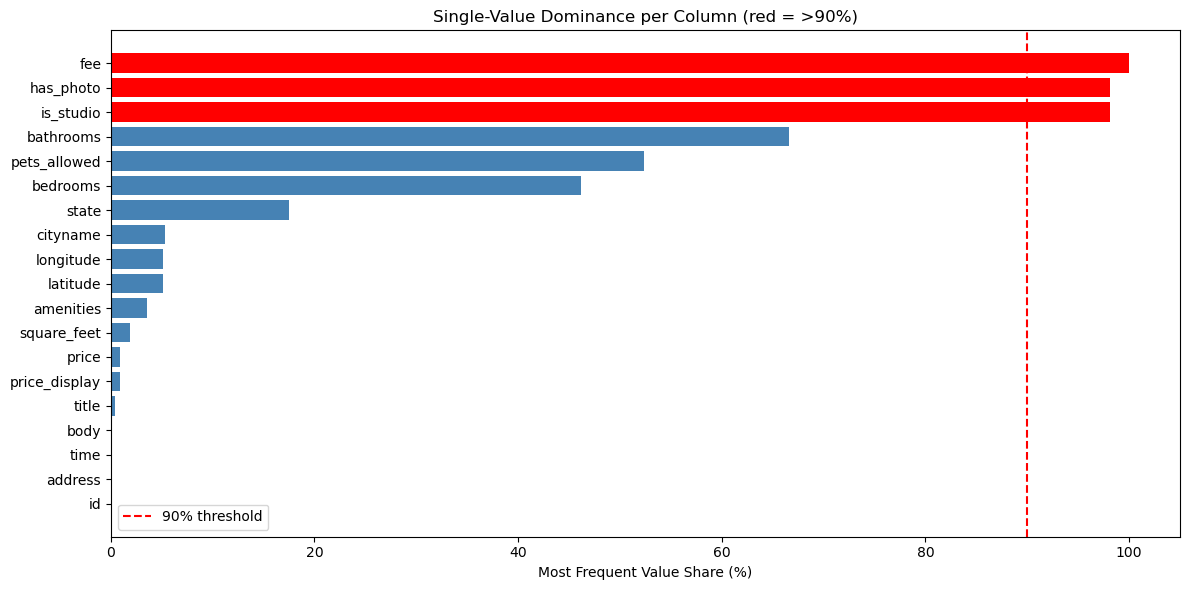

In [24]:
# Visualise: bar chart of single-value dominance per column
plt.figure(figsize=(12, 6))
colors = ['red' if v > 90 else 'steelblue' for v in dominance.values]
plt.barh(dominance.index, dominance.values, color=colors)
plt.axvline(x=90, color='red', linestyle='--', label='90% threshold')
plt.xlabel('Most Frequent Value Share (%)')
plt.title('Single-Value Dominance per Column (red = >90%)')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [25]:
# drop columns with more than 90% single-value dominance
# has_photo has 98% dominance but keeping for meaningful 2% variation
df.drop(columns=['fee','is_studio'], inplace=True)

dropping fee and is_studio, this specific feature remains way past the 90% red-line threshold, making it pretty much useless for finding patterns. It is essentially a constant, so removing it allows the analysis to focus on the other columns

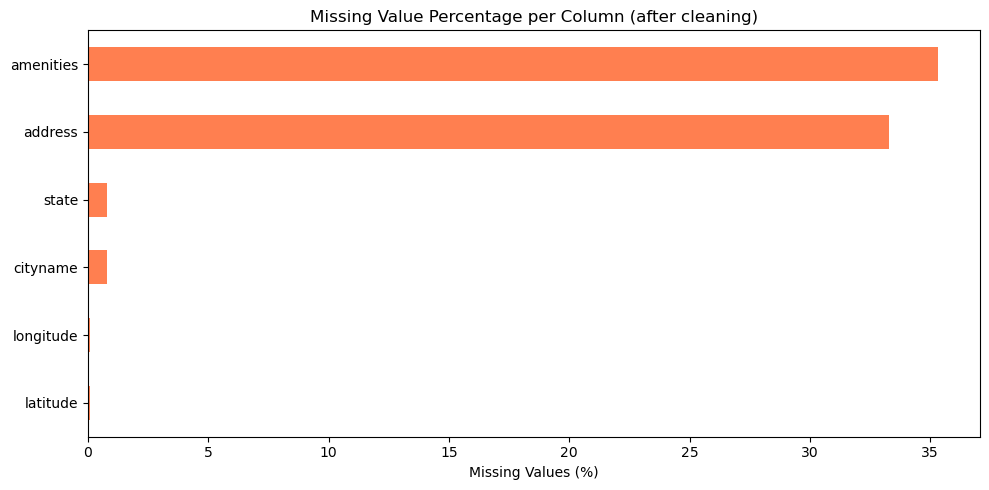

In [26]:
# Missing value % per column (bar chart)
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(10, 5))
missing_pct.plot(kind='barh', color='coral')
plt.xlabel('Missing Values (%)')
plt.title('Missing Value Percentage per Column (after cleaning)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [27]:
# High cardinality check for categorical columns
cat_cols = df.select_dtypes(include='object').columns
print("=== Unique values per categorical column ===")
for col in cat_cols:
    n = df[col].nunique()
    print(f"  {col}: {n} unique values")

print(f"\ncityname has {df['cityname'].nunique()} cities — will use top 20 or aggregate by state for modelling")
print(f"state has {df['state'].nunique()} states")

=== Unique values per categorical column ===
  title: 9308 unique values
  body: 9918 unique values
  amenities: 2247 unique values
  has_photo: 2 unique values
  pets_allowed: 4 unique values
  price_display: 1724 unique values
  address: 6629 unique values
  cityname: 1572 unique values
  state: 51 unique values

cityname has 1572 cities — will use top 20 or aggregate by state for modelling
state has 51 states


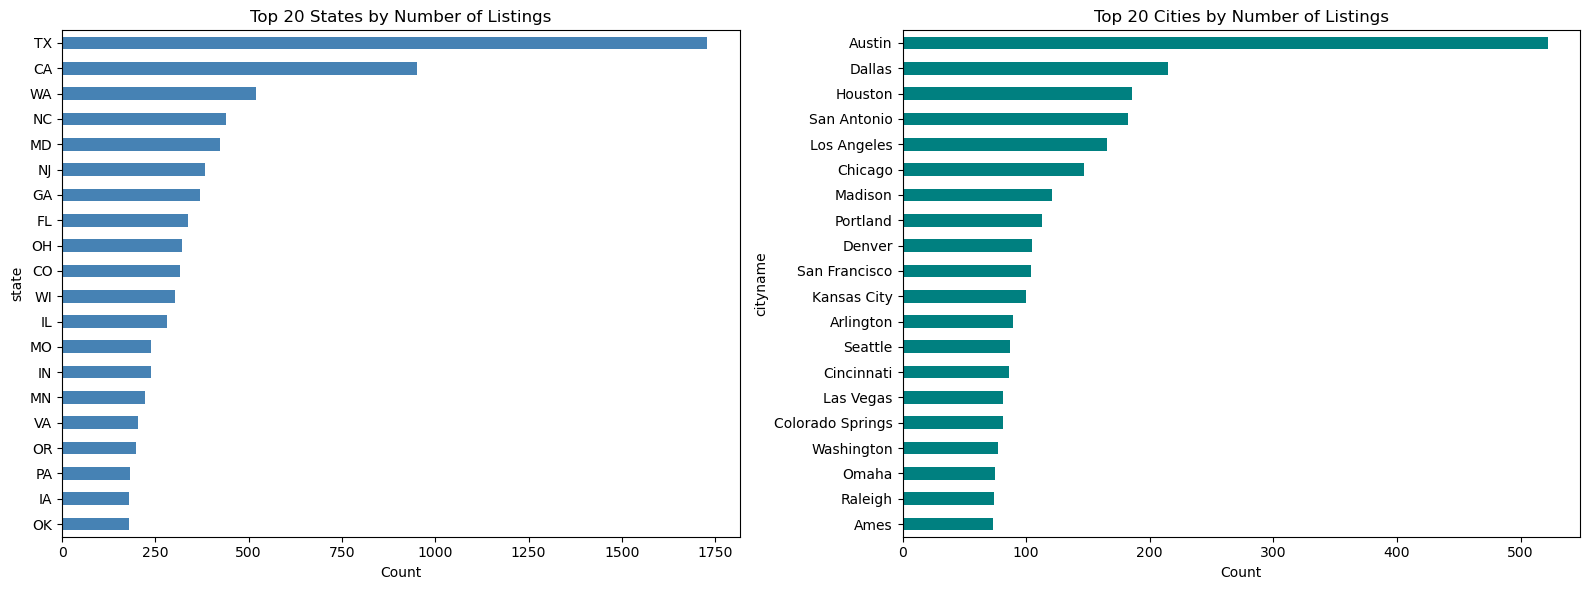

In [28]:
# Top 20 cities and states by listing count
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df['state'].value_counts().head(20).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 States by Number of Listings')
axes[0].set_xlabel('Count')
axes[0].invert_yaxis()

df['cityname'].value_counts().head(20).plot(kind='barh', ax=axes[1], color='teal')
axes[1].set_title('Top 20 Cities by Number of Listings')
axes[1].set_xlabel('Count')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

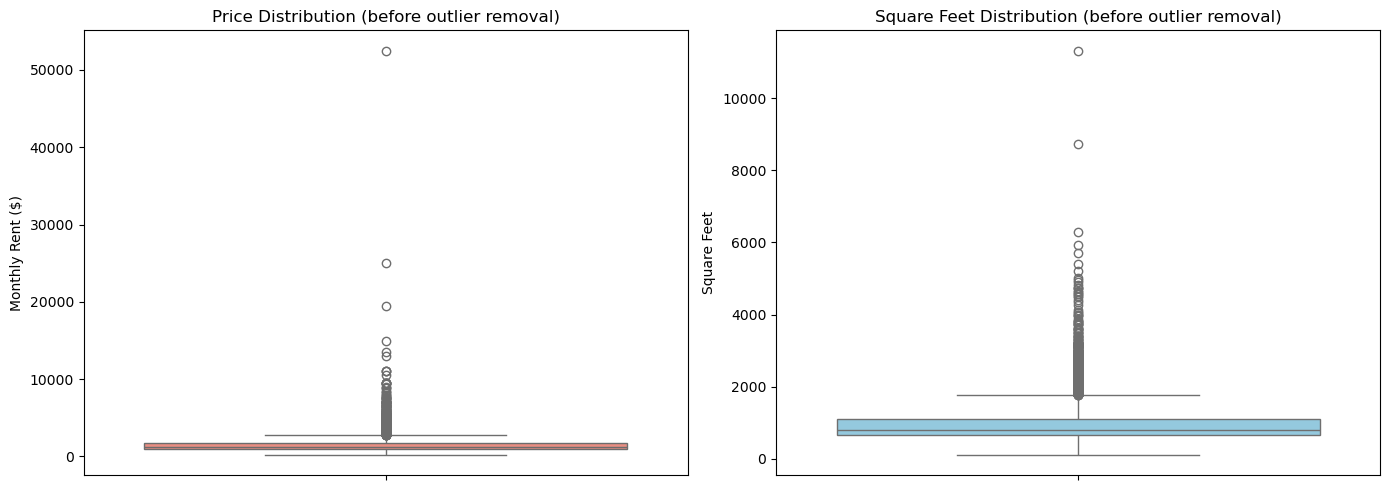

Shape before outlier removal: (9957, 17)


In [29]:
# Boxplots of price and square_feet BEFORE outlier removal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=df['price'], ax=axes[0], color='salmon')
axes[0].set_title('Price Distribution (before outlier removal)')
axes[0].set_ylabel('Monthly Rent ($)')

sns.boxplot(y=df['square_feet'], ax=axes[1], color='skyblue')
axes[1].set_title('Square Feet Distribution (before outlier removal)')
axes[1].set_ylabel('Square Feet')

plt.tight_layout()
plt.show()

print(f"Shape before outlier removal: {df.shape}")

In [30]:
# Remove outliers using IQR method for price and square_feet
def remove_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = len(dataframe)
    dataframe = dataframe[(dataframe[column] >= lower) & (dataframe[column] <= upper)]
    after = len(dataframe)
    print(f"  {column}: removed {before - after} rows  |  bounds: [{lower:.0f}, {upper:.0f}]")
    return dataframe

print("=== IQR Outlier Removal ===")
df = remove_outliers_iqr(df, 'price')
df = remove_outliers_iqr(df, 'square_feet')
print(f"\nShape after outlier removal: {df.shape}")

=== IQR Outlier Removal ===
  price: removed 615 rows  |  bounds: [-170, 2814]
  square_feet: removed 511 rows  |  bounds: [12, 1688]

Shape after outlier removal: (8831, 17)


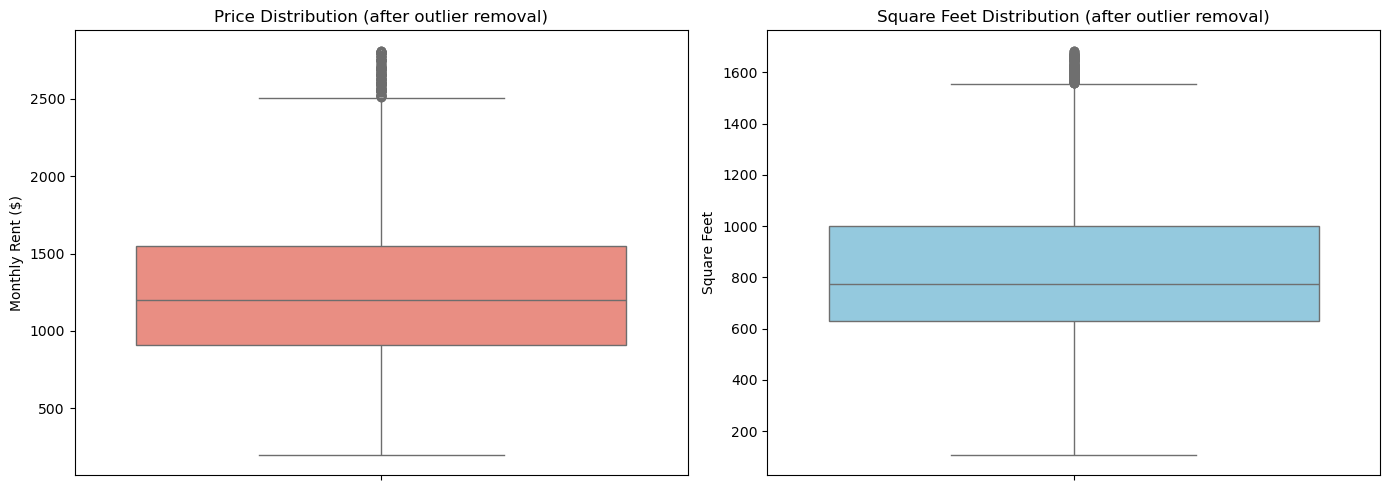

In [31]:
# Boxplots AFTER outlier removal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=df['price'], ax=axes[0], color='salmon')
axes[0].set_title('Price Distribution (after outlier removal)')
axes[0].set_ylabel('Monthly Rent ($)')

sns.boxplot(y=df['square_feet'], ax=axes[1], color='skyblue')
axes[1].set_title('Square Feet Distribution (after outlier removal)')
axes[1].set_ylabel('Square Feet')

plt.tight_layout()
plt.show()

### Exploratory Data Analysis (EDA)


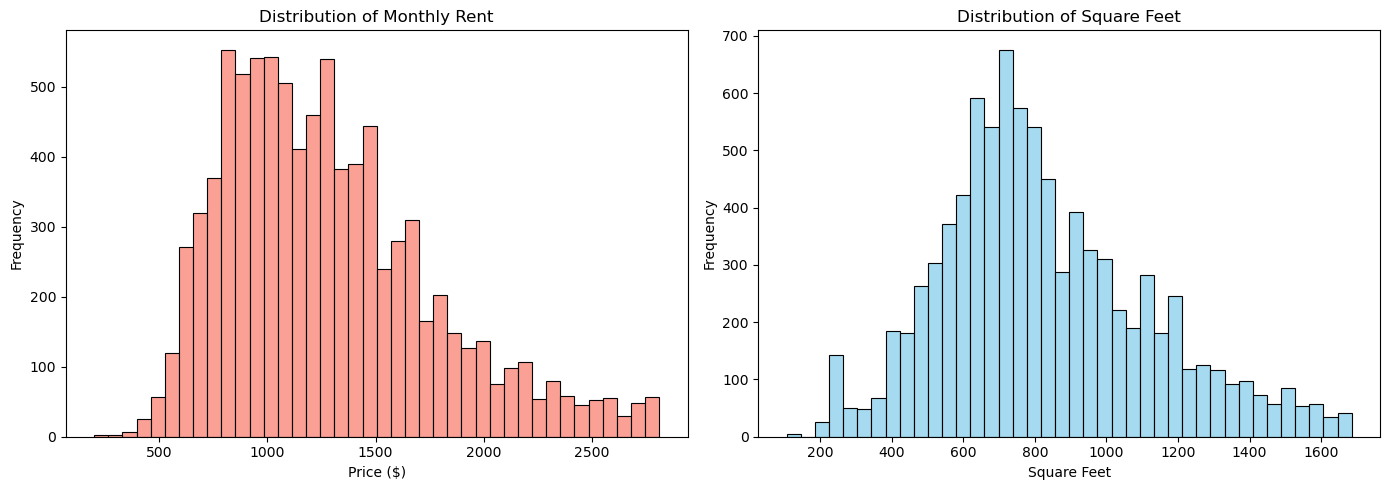

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price
sns.histplot(
    df['price'],
    bins=40,
    ax=axes[0],
    color='salmon',
    edgecolor='black'
)
axes[0].set_title('Distribution of Monthly Rent')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')

# Optional if skewed:
# axes[0].set_xscale('log')

# Square Feet
sns.histplot(
    df['square_feet'],
    bins=40,
    ax=axes[1],
    color='skyblue',
    edgecolor='black'
)
axes[1].set_title('Distribution of Square Feet')
axes[1].set_xlabel('Square Feet')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

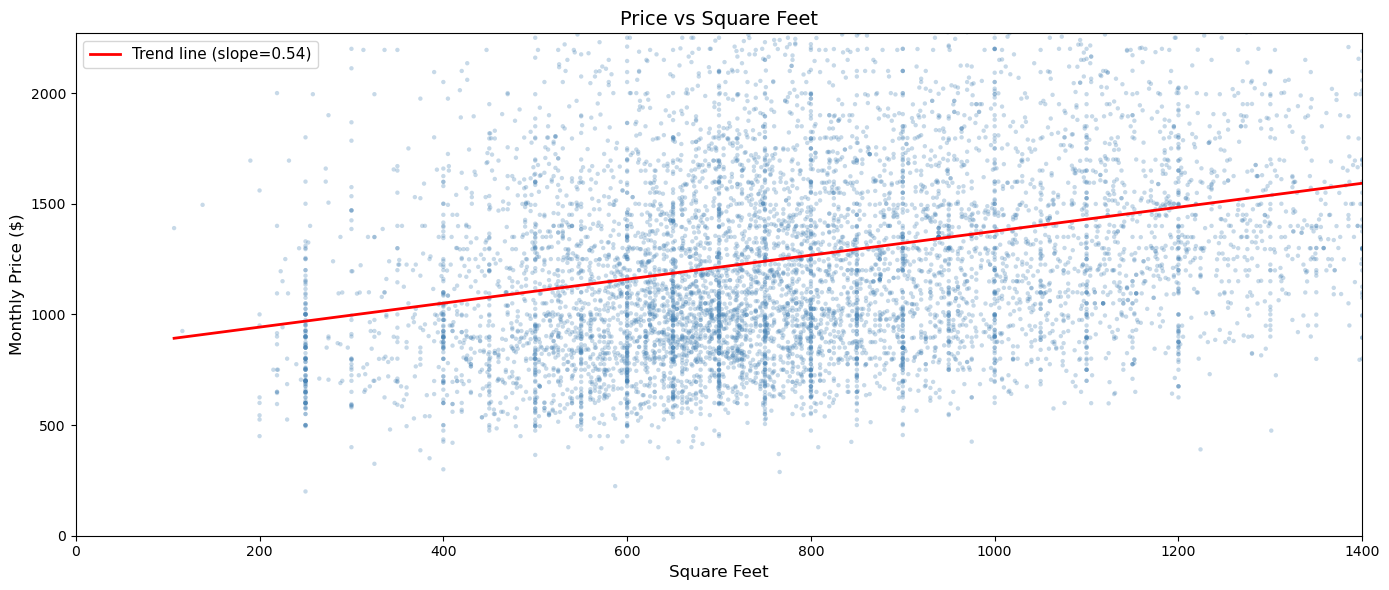

In [33]:
# Scatterplot — Price vs Square Feet
fig, ax = plt.subplots(figsize=(14, 6))

ax.scatter(df['square_feet'], df['price'], alpha=0.3, s=10, color='steelblue', edgecolors='none')

# Add trend line
z = np.polyfit(df['square_feet'].dropna(), df.loc[df['square_feet'].notna(), 'price'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['square_feet'].min(), df['square_feet'].quantile(0.95), 100)
ax.plot(x_line, p(x_line), color='red', linewidth=2, label=f'Trend line (slope={z[0]:.2f})')

ax.set_xlim(0, df['square_feet'].quantile(0.95))
ax.set_ylim(0, df['price'].quantile(0.95))
ax.set_xlabel('Square Feet', fontsize=12)
ax.set_ylabel('Monthly Price ($)', fontsize=12)
ax.set_title('Price vs Square Feet', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

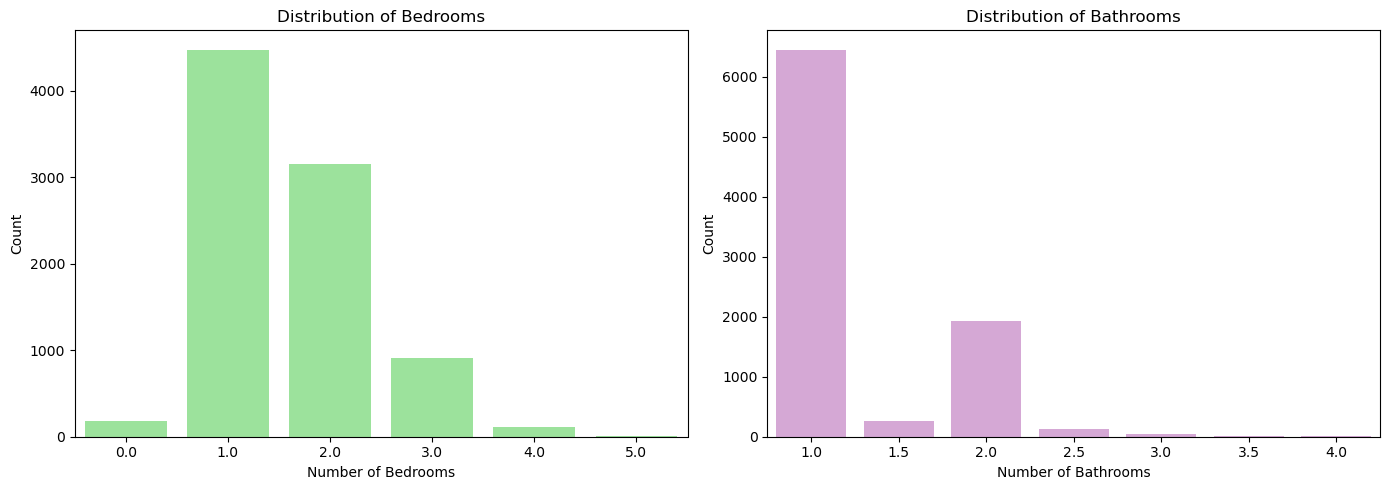

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bedrooms
sns.countplot(
    x='bedrooms',
    data=df,
    ax=axes[0],
    color='lightgreen'
)
axes[0].set_title('Distribution of Bedrooms')
axes[0].set_xlabel('Number of Bedrooms')
axes[0].set_ylabel('Count')

# Bathrooms
sns.countplot(
    x='bathrooms',
    data=df,
    ax=axes[1],
    color='plum'
)
axes[1].set_title('Distribution of Bathrooms')
axes[1].set_xlabel('Number of Bathrooms')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

1.5 bathrooms = 1 full bath (toilet + sink + shower/tub) + 1 half bath (toilet + sink only)

2.5 bathrooms = 2 full baths + 1 half bath

3.5 bathrooms = 3 full baths + 1 half bath

/var/folders/x4/k7_nkprd0q3bw82ysv293f4h0000gn/T/ipykernel_19095/1647425876.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/var/folders/x4/k7_nkprd0q3bw82ysv293f4h0000gn/T/ipykernel_19095/1647425876.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


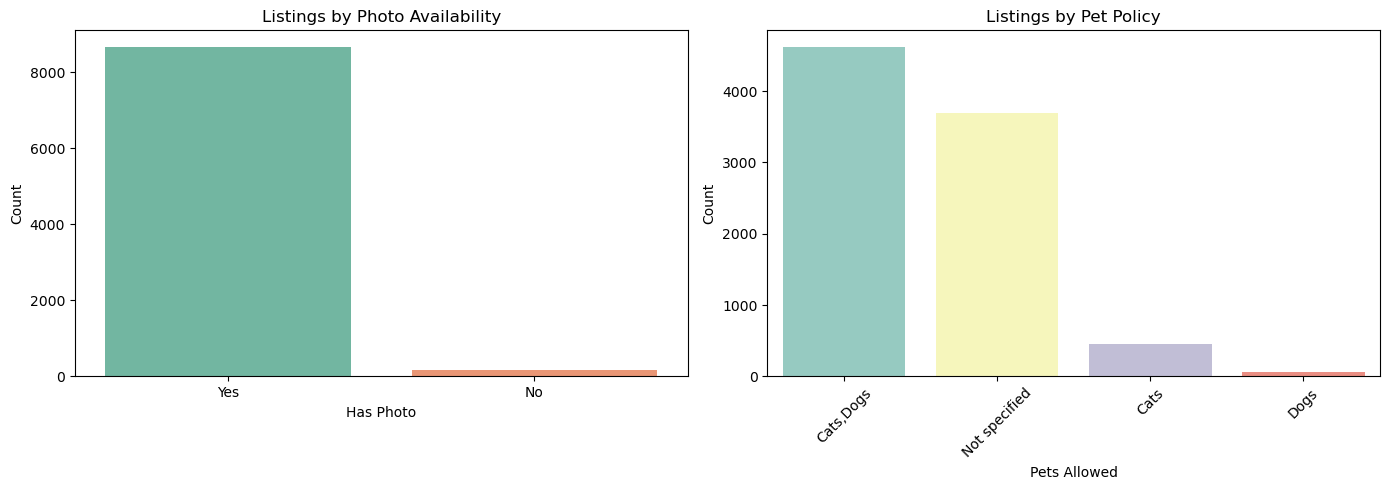

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Has Photo
sns.countplot(
    data=df,
    x='has_photo',
    ax=axes[0],
    palette='Set2'
)
axes[0].set_title('Listings by Photo Availability')
axes[0].set_xlabel('Has Photo')
axes[0].set_ylabel('Count')

# Pets Allowed
pets_order = df['pets_allowed'].value_counts().index
sns.countplot(
    data=df,
    x='pets_allowed',
    order=pets_order,
    ax=axes[1],
    palette='Set3'
)
axes[1].set_title('Listings by Pet Policy')
axes[1].set_xlabel('Pets Allowed')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

##### which square footage and price range is the highest density of rental inventory concentrated, and what does this reveal about the 'standard' apartment in the market?

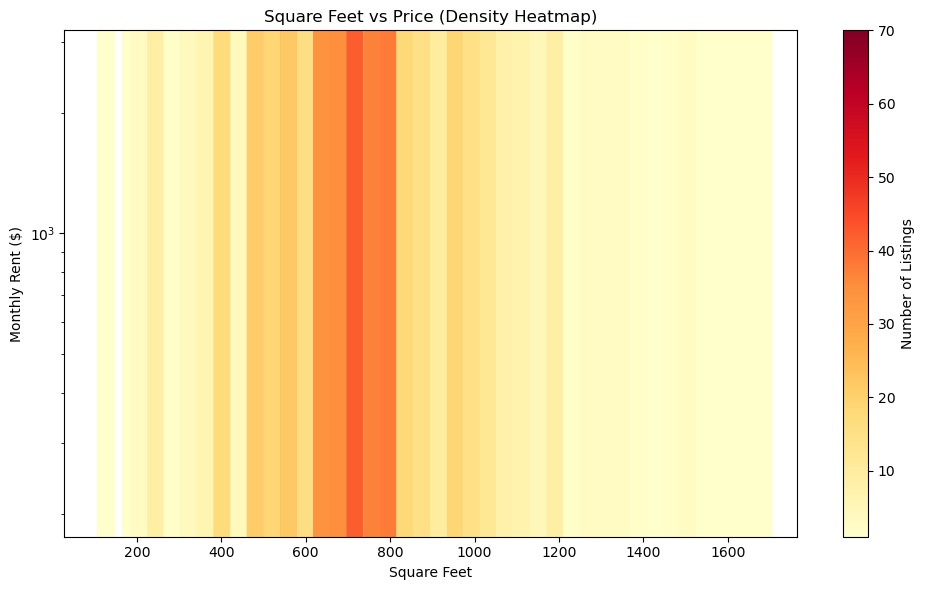

In [36]:
# Create price_per_sqft feature
df['price_per_sqft'] = df['price'] / df['square_feet']

# Remove infinite values if square_feet has zeros
df = df[df['square_feet'] > 0]

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Hexbin plot (density-based visualization)
hb = ax.hexbin(
    df['square_feet'],
    df['price'],
    gridsize=40,           # more resolution
    cmap='YlOrRd',
    mincnt=1
)

# Labels and title
ax.set_xlabel('Square Feet')
ax.set_ylabel('Monthly Rent ($)')
ax.set_title('Square Feet vs Price (Density Heatmap)')

# Optional: log scale if price is skewed
ax.set_yscale('log')

# Colorbar
cb = fig.colorbar(hb, ax=ax)
cb.set_label('Number of Listings')

plt.tight_layout()
plt.show()


The heatmap shows that most rental listings are concentrated between 600 and 800 square feet, which creates the bright orange vertical "heat" zone. Even for apartments of the same size, there is a very wide range of monthly rent prices available across the market. The layout makes it easy to spot outliers, such as small units that are unusually expensive or large units with surprisingly low rent

#### How do apartment size and bedroom count influence the price per square foot across the rental market, and at what point does 'bulk value' peak for renters?

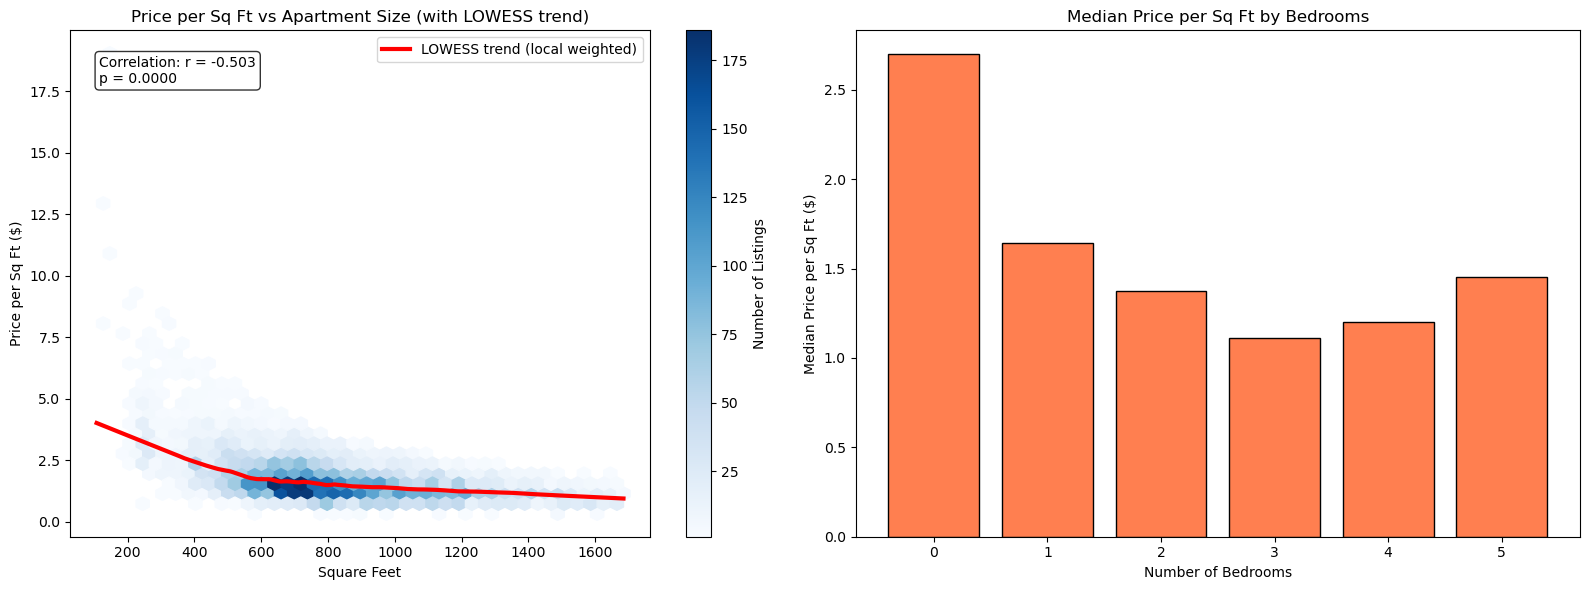

In [37]:
# Remove invalid values first
df = df[(df['square_feet'] > 0) & (df['price_per_sqft'] > 0)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -------------------------
# 1) Hexbin Plot with LOWESS curve (non-linear trend)
# -------------------------
from scipy.stats import pearsonr
from statsmodels.nonparametric.smoothers_lowess import lowess

hb = axes[0].hexbin(
    df['square_feet'],
    df['price_per_sqft'],
    gridsize=40,
    cmap='Blues',
    mincnt=1
)

axes[0].set_xlabel('Square Feet')
axes[0].set_ylabel('Price per Sq Ft ($)')
axes[0].set_title('Price per Sq Ft vs Apartment Size (with LOWESS trend)')

# LOWESS curve (flexible, non-linear trend following the data)
lowess_result = lowess(df['price_per_sqft'], df['square_feet'], frac=0.1)
axes[0].plot(
    lowess_result[:, 0],
    lowess_result[:, 1],
    'r-',
    linewidth=3,
    label='LOWESS trend (local weighted)'
)

# Calculate correlation only
r_value, p_value = pearsonr(df['square_feet'], df['price_per_sqft'])

axes[0].legend()
axes[0].text(
    0.05, 0.95,
    f'Correlation: r = {r_value:.3f}\np = {p_value:.4f}',
    transform=axes[0].transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

cb = fig.colorbar(hb, ax=axes[0])
cb.set_label('Number of Listings')


# -------------------------
# 2) Median Price per Sqft by Bedrooms
# -------------------------
median_ppsf_bedrooms = (
    df.groupby('bedrooms')['price_per_sqft']
    .median()
    .reset_index()
)

axes[1].bar(
    median_ppsf_bedrooms['bedrooms'],
    median_ppsf_bedrooms['price_per_sqft'],
    color='coral',
    edgecolor='black'
)

axes[1].set_xlabel('Number of Bedrooms')
axes[1].set_ylabel('Median Price per Sq Ft ($)')
axes[1].set_title('Median Price per Sq Ft by Bedrooms')

plt.tight_layout()
plt.show()




The red LOWESS curve is a much better fit because it follows the natural bend of the data instead of forcing a straight line. It clearly shows that the price for each square foot starts very high for tiny apartments but drops quickly as the units get bigger. Most listings are clustered in the middle, where the price finally starts to level out and become more consistent. This chart proves that while larger apartments cost more total, you actually get a better deal on the price per square foot as the size increases.


The bar chart shows that median price per square foot is highest for studios (0 bedrooms) and drops significantly as the bedroom count increases. The cost hits its lowest point at 3 bedrooms, but starts to climb again for 4 and 5-bedroom units. This confirms that smaller apartments are the most expensive per foot, while mid-sized family homes offer the best value. The slight rise for 5-bedroom units likely reflects a premium for rare, luxury-sized properties in the market.

### Does Mean/Median rent differ by number of bedrooms?

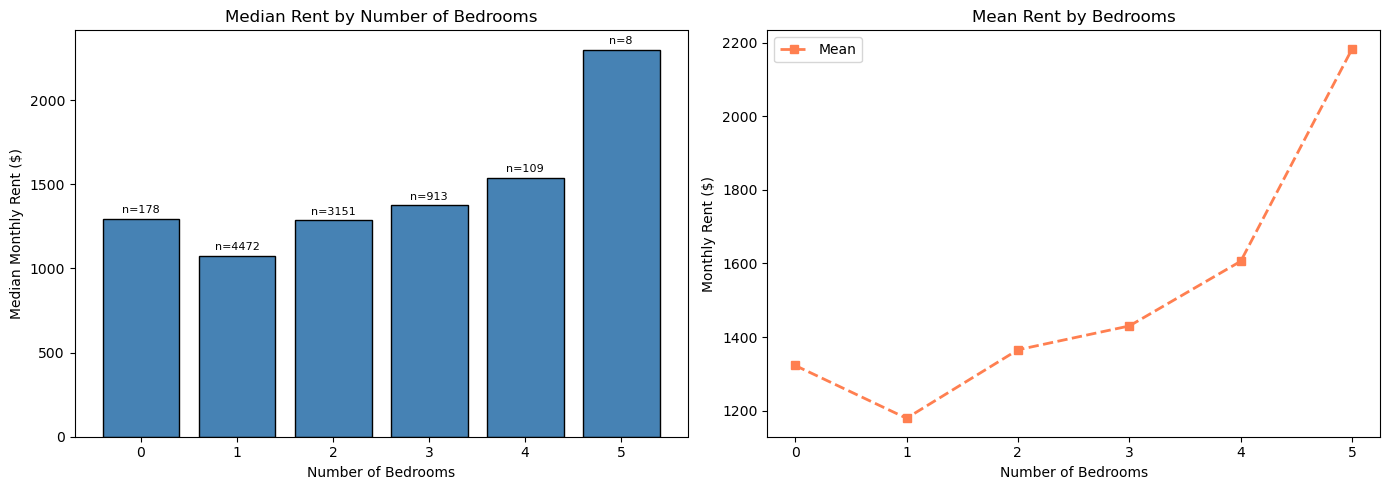

In [38]:
# Median price per number of bedrooms (line/bar chart)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: median price by bedrooms
median_price_bed = df.groupby('bedrooms')['price'].agg(['median', 'mean', 'count']).reset_index()
bars = axes[0].bar(median_price_bed['bedrooms'], median_price_bed['median'], color='steelblue', edgecolor='black')
axes[0].set_xlabel('Number of Bedrooms')
axes[0].set_ylabel('Median Monthly Rent ($)')
axes[0].set_title('Median Rent by Number of Bedrooms')
# Add count labels on bars
for i, (bar, count) in enumerate(zip(bars, median_price_bed['count'])):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, f'n={int(count)}', 
                 ha='center', va='bottom', fontsize=8)

# Line chart: median and mean price by bedrooms
axes[1].plot(median_price_bed['bedrooms'], median_price_bed['mean'], marker='s', label='Mean', linewidth=2, color='coral', linestyle='--')
axes[1].set_xlabel('Number of Bedrooms')
axes[1].set_ylabel('Monthly Rent ($)')
axes[1].set_title('Mean Rent by Bedrooms')
axes[1].legend()

plt.tight_layout()
plt.show()

The total monthly rent shows a surprising trend where studios actually cost more than one-bedroom apartments on average. Once past the one-bedroom mark, the price starts to climb steadily for every extra bedroom included in the unit. There is a major price jump for five-bedroom homes, likely because these large properties are rare and cater to the high-end market. 

Note: most of the apartments with 1 bedroom

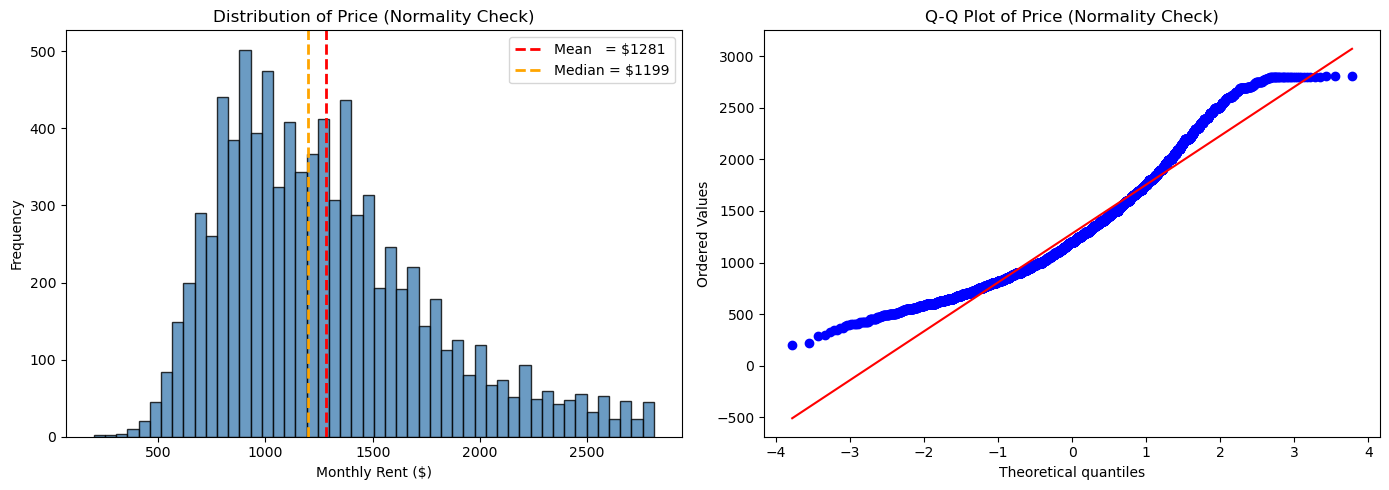

it's okay we can still use anova


In [39]:
# we can use anova to test if the mean price differs by number of bedrooms, but first we need to check the normality of the price distribution and the homogeneity of variances
#Normality check: histogram + Q-Q plot of price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['price'], bins=50, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(df['price'].mean(),   color='red',    linestyle='--', linewidth=2, label=f"Mean   = ${df['price'].mean():.0f}")
axes[0].axvline(df['price'].median(), color='orange', linestyle='--', linewidth=2, label=f"Median = ${df['price'].median():.0f}")
axes[0].set_xlabel('Monthly Rent ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Price (Normality Check)')
axes[0].legend()

# Q-Q plot
stats.probplot(df['price'], dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of Price (Normality Check)')

plt.tight_layout()
plt.show()

print("it's okay we can still use anova")


/var/folders/x4/k7_nkprd0q3bw82ysv293f4h0000gn/T/ipykernel_19095/1834373868.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='bedrooms', y='price', palette='Set2')


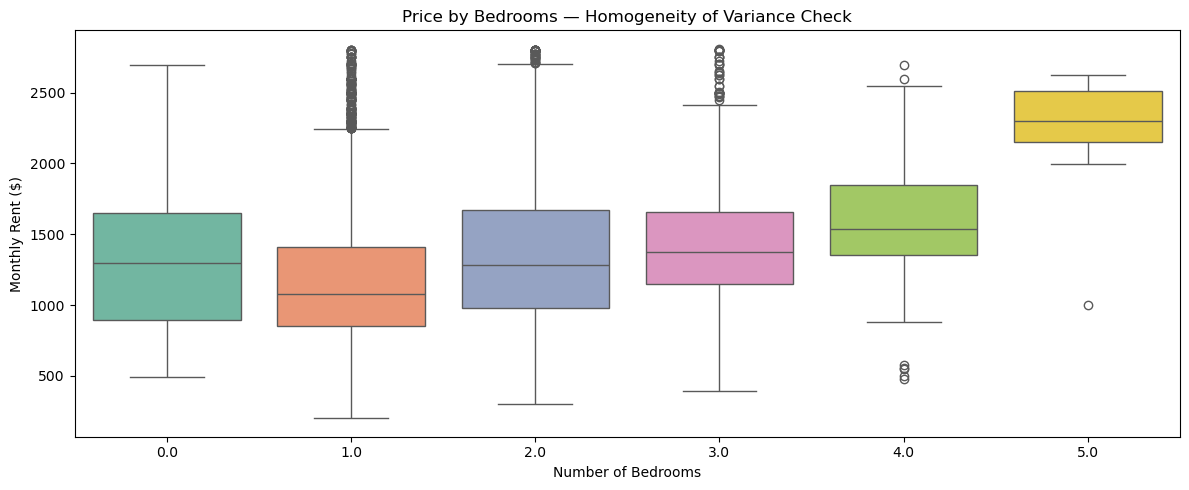

In [40]:
# Homogeneity of variance: boxplot price by bedrooms
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='bedrooms', y='price', palette='Set2')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Monthly Rent ($)')
plt.title('Price by Bedrooms — Homogeneity of Variance Check')
plt.tight_layout()
plt.show()


The boxplot shows that the spread of price differs considerably across bedroom groups — the variance clearly increases with bedroom count. This **violates the homogeneity of variance assumption** of standard one-way ANOVA.

We therefore use **Welch’s ANOVA**, which relaxes the equal-variance requirement and is robust to unequal group variances.

In [41]:
import pingouin as pg

# Welch's ANOVA — does not assume equal variances
welch_result = pg.welch_anova(data=df, dv='price', between='bedrooms')

print("=== Welch's ANOVA: Price ~ Bedrooms ===")
print(welch_result[['Source', 'ddof1', 'ddof2', 'F', 'p-unc', 'np2']].to_string(index=False))
print()
if welch_result['p-unc'].values[0] < 0.05:
    print("→ Significant: rent differs across bedroom groups (p < 0.05). Proceeding with post-hoc.")
else:
    print("→ Not significant: no evidence that rent differs across bedroom groups.")


=== Welch's ANOVA: Price ~ Bedrooms ===
  Source  ddof1     ddof2         F        p-unc      np2
bedrooms      5 73.744312 93.877151 1.517475e-30 0.051313

→ Significant: rent differs across bedroom groups (p < 0.05). Proceeding with post-hoc.


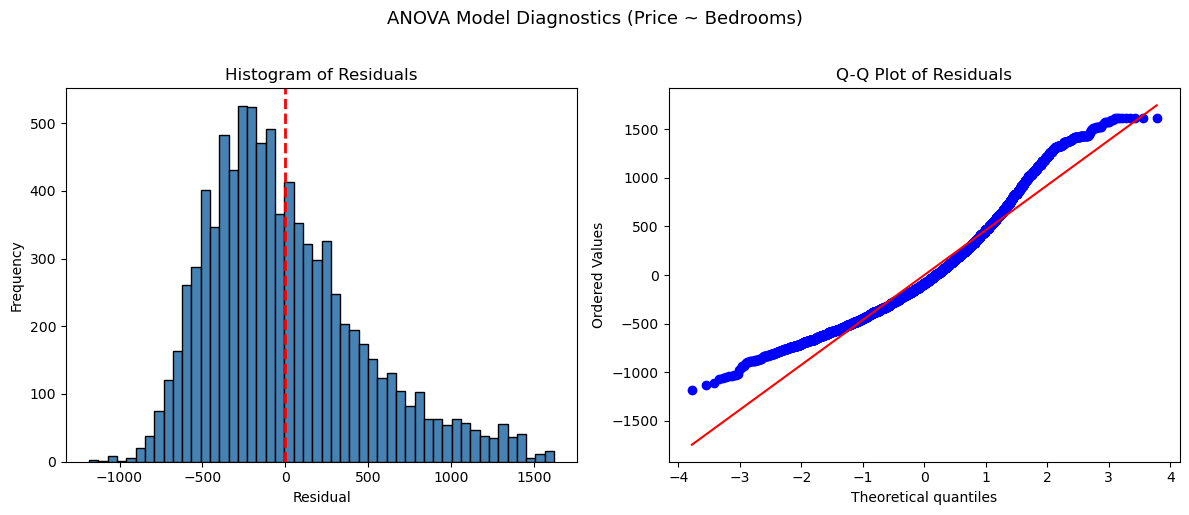

In [42]:
import scipy.stats as stats
df['group_mean_bed'] = df.groupby('bedrooms')['price'].transform('mean')
df['residuals_anova'] = df['price'] - df['group_mean_bed']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['residuals_anova'], bins=50, color='steelblue', edgecolor='black')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Residual')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Histogram of Residuals')


stats.probplot(df['residuals_anova'], dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

plt.suptitle('ANOVA Model Diagnostics (Price ~ Bedrooms)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Clean up temporary columns
df.drop(columns=['group_mean_bed', 'residuals_anova'], inplace=True)

In [43]:
# ── Games-Howell post-hoc: which bedroom pairs differ? ──────────────────
gh = pg.pairwise_gameshowell(data=df, dv='price', between='bedrooms')

print("Games-Howell Post-hoc: Price by Bedrooms")
print(gh[['A', 'B', 'mean(A)', 'mean(B)', 'diff', 'se', 'pval']].to_string(index=False))


Games-Howell Post-hoc: Price by Bedrooms
  A   B     mean(A)     mean(B)         diff         se         pval
0.0 1.0 1322.915730 1179.488596   143.427135  39.381404 4.651828e-03
0.0 2.0 1322.915730 1365.433831   -42.518100  39.842594 8.938112e-01
0.0 3.0 1322.915730 1430.269441  -107.353711  41.659040 1.070903e-01
0.0 4.0 1322.915730 1606.009174  -283.093444  59.302560 4.541032e-05
0.0 5.0 1322.915730 2183.125000  -860.209270 187.762211 1.666875e-02
1.0 2.0 1179.488596 1365.433831  -185.945235  11.275389 3.093859e-12
1.0 3.0 1179.488596 1430.269441  -250.780846  16.588482 0.000000e+00
1.0 4.0 1179.488596 1606.009174  -426.520579  45.348602 2.731149e-14
1.0 5.0 1179.488596 2183.125000 -1003.636404 183.832396 7.687266e-03
2.0 3.0 1365.433831 1430.269441   -64.835611  17.655452 3.381599e-03
2.0 4.0 1365.433831 1606.009174  -240.575344  45.749677 9.746813e-06
2.0 5.0 1365.433831 2183.125000  -817.691169 183.931746 2.298064e-02
3.0 4.0 1430.269441 1606.009174  -175.739733  47.340008 3.9952

Does the rent change from city/state to city/state ?

Which states and cities have the highest rents?

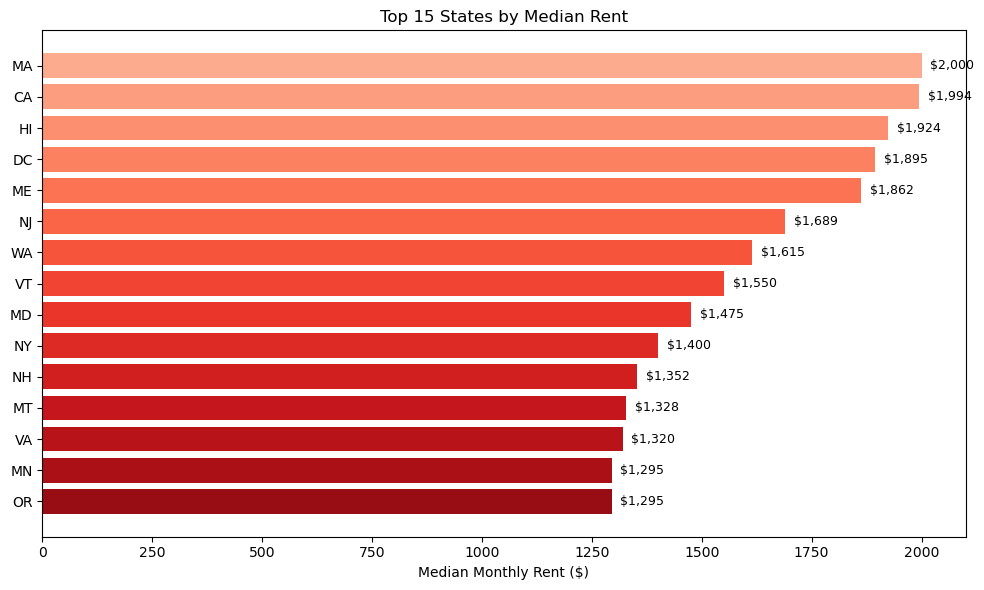

In [44]:
# Top 15 States by median rent
state_median = df.groupby('state')['price'].median().sort_values(ascending=False).head(15)
colors_state = plt.cm.Reds(np.linspace(0.3, 0.9, len(state_median)))

plt.figure(figsize=(10, 6))
plt.barh(state_median.index[::-1], state_median.values[::-1], color=colors_state[::-1])
plt.xlabel('Median Monthly Rent ($)')
plt.title('Top 15 States by Median Rent')

# Annotate values
for i, (state, val) in enumerate(zip(state_median.index[::-1], state_median.values[::-1])):
    plt.text(val + 20, i, f'${val:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()



In [45]:
import plotly.express as px
    # Calculate mean rent by state
state_rent = df.groupby('state')['price'].mean().reset_index()
state_rent.columns = ['state', 'avg_rent']
    
fig = px.choropleth(
        state_rent,
        locations='state',
        locationmode='USA-states',
        color='avg_rent',
        color_continuous_scale='Reds',
        scope='usa',
        title='Average Monthly Rent by State',
        labels={'avg_rent': 'Avg Rent ($)'}
    )
fig.update_layout(geo=dict(bgcolor='rgba(0,0,0,0)'))
fig.show()

The rent map and bar chart show that where you live is a huge deal for your wallet. Massachusetts and California are the most expensive, with middle-range rents hitting about $2,000, while Hawaii and DC aren't far behind. On the other hand, a lot of states in the middle of the country are much cheaper, often staying well under $1,000. Basically, you can pay twice as much for a place just by crossing into a different state.

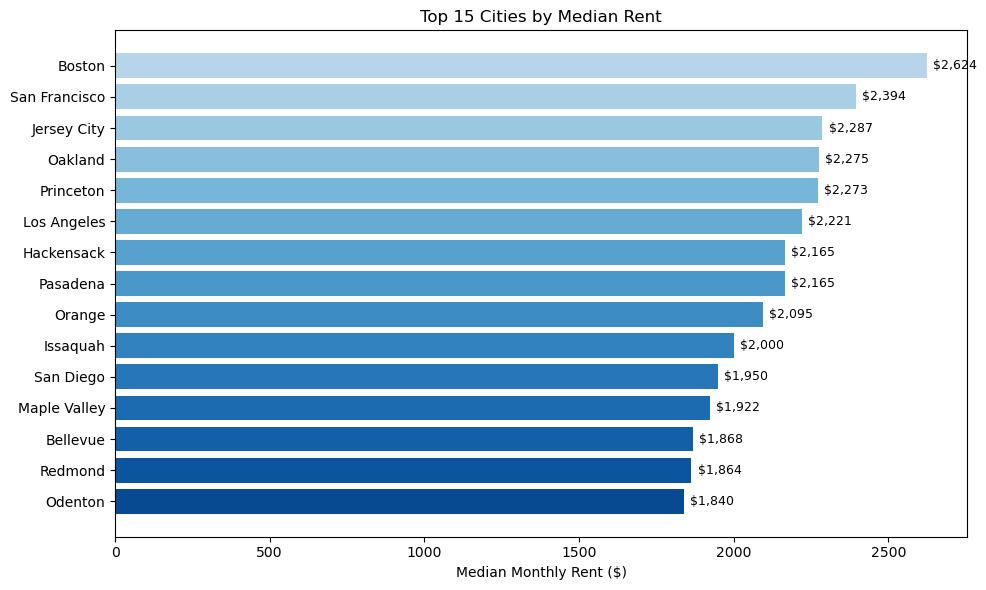

In [46]:
# Filter cities with at least 10 listings
city_counts = df['cityname'].value_counts()
cities_min10 = city_counts[city_counts >= 10].index
df_filtered = df[df['cityname'].isin(cities_min10)]

# Top 15 Cities by median rent
city_median = df_filtered.groupby('cityname')['price'].median().sort_values(ascending=False).head(15)
colors_city = plt.cm.Blues(np.linspace(0.3, 0.9, len(city_median)))

plt.figure(figsize=(10, 6))
plt.barh(city_median.index[::-1], city_median.values[::-1], color=colors_city[::-1])
plt.xlabel('Median Monthly Rent ($)')
plt.title('Top 15 Cities by Median Rent')

# Annotate values
for i, (city, val) in enumerate(zip(city_median.index[::-1], city_median.values[::-1])):
    plt.text(val + 20, i, f'${val:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

While individual cities like Boston and San Francisco have the highest rents, they also drive up the overall cost of their states. Because Boston is so expensive, it helps push Massachusetts to the #1 spot on the state list with a $2,000 median rent. Similarly, the high costs in San Francisco, Los Angeles, and San Diego make California the second most expensive state at $1,994. Essentially, these "expensive" states aren't pricey everywhere; they are being pulled up by a handful of high-demand cities that charge a massive premium.

In [47]:
# Extract time features 
df['listing_date'] = pd.to_datetime(df['time'], unit='s')
df['listing_year'] = df['listing_date'].dt.year
df['listing_month'] = df['listing_date'].dt.month
df['listing_yearmonth'] = df['listing_date'].dt.to_period('M')

print("=== Temporal Coverage ===")
print(f"Earliest listing: {df['listing_date'].min()}")
print(f"Latest listing: {df['listing_date'].max()}")
time_span = (df['listing_date'].max() - df['listing_date'].min()).days
print(f"Time span: {time_span} days (~{time_span/30:.1f} months)")

=== Temporal Coverage ===
Earliest listing: 2019-09-17 18:12:56
Latest listing: 2019-12-26 12:09:01
Time span: 99 days (~3.3 months)


Dataset covers only ~4 months — insufficient for seasonality analysis

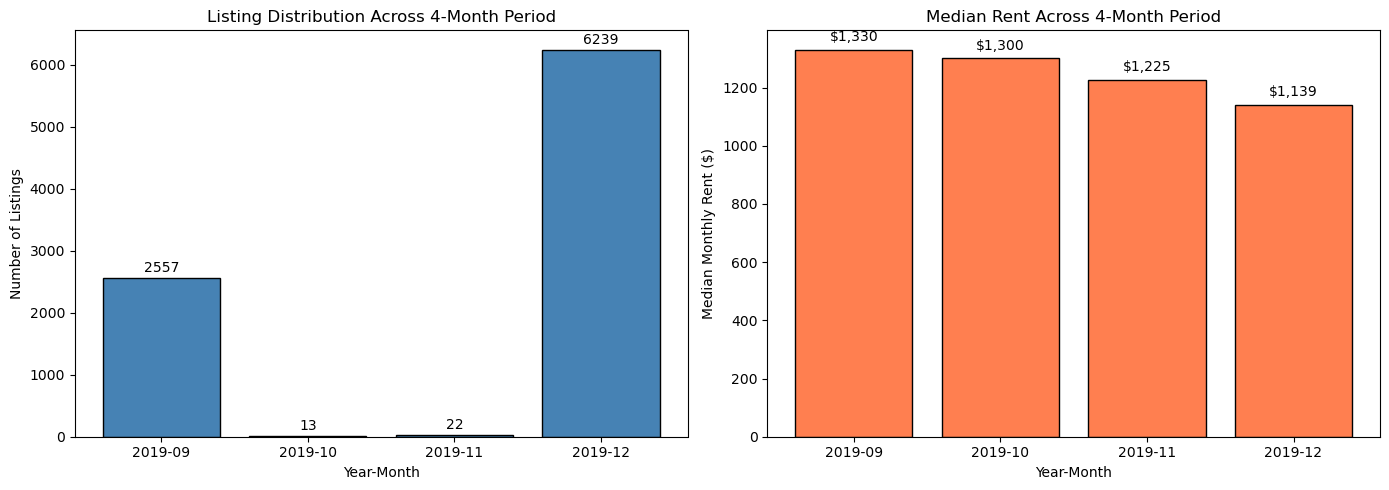


No seasonality analysis performed — insufficient temporal coverage.
Prices appear relatively stable across this 4-month window.


In [48]:
# Simple visualization of the 4-month snapshot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Listings by year-month (only the months we have)
listings_by_month = df.groupby('listing_yearmonth').size().sort_index()
axes[0].bar(range(len(listings_by_month)), listings_by_month.values, color='steelblue', edgecolor='black')
axes[0].set_xticks(range(len(listings_by_month)))
axes[0].set_xticklabels([str(m) for m in listings_by_month.index], rotation=0)
axes[0].set_xlabel('Year-Month')
axes[0].set_ylabel('Number of Listings')
axes[0].set_title('Listing Distribution Across 4-Month Period')
for i, v in enumerate(listings_by_month.values):
    axes[0].text(i, v + 50, str(v), ha='center', va='bottom', fontsize=10)

# Median price by year-month
median_price_by_month = df.groupby('listing_yearmonth')['price'].median().sort_index()
axes[1].bar(range(len(median_price_by_month)), median_price_by_month.values, color='coral', edgecolor='black')
axes[1].set_xticks(range(len(median_price_by_month)))
axes[1].set_xticklabels([str(m) for m in median_price_by_month.index], rotation=0)
axes[1].set_xlabel('Year-Month')
axes[1].set_ylabel('Median Monthly Rent ($)')
axes[1].set_title('Median Rent Across 4-Month Period')
for i, v in enumerate(median_price_by_month.values):
    axes[1].text(i, v + 20, f'${v:,.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


print(f"\nNo seasonality analysis performed — insufficient temporal coverage.")
print(f"Prices appear relatively stable across this 4-month window.")

### PCA

Can we summarise apartment characteristics in 2–3 dimensions without losing much information?


In [49]:
#  StandardScaler on numeric features (will be used later for PCA & clustering)
# working on another dataframe not the original one(df)
from sklearn.preprocessing import StandardScaler

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
# Remove 'id' and 'time' from scaling — they are identifiers, not features
scale_cols = [c for c in numeric_cols if c not in ['id', 'time']]

pca_scaler = StandardScaler()
df_scaled_preview = pd.DataFrame(pca_scaler.fit_transform(df[scale_cols]), columns=scale_cols, index=df.index)

print("=== Scaled Features (first 5 rows) ===")
df_scaled_preview.head()

=== Scaled Features (first 5 rows) ===


,bathrooms,bedrooms,price,square_feet,latitude,longitude,price_per_sqft
2,-0.578734,-2.089125,0.224431,-2.457171,0.203344,1.112769,12.977456
3,-0.578734,-2.089125,-0.731494,-2.426348,1.770652,-1.868298,7.207274
5,-0.578734,-2.089125,2.454923,-2.378403,0.539601,1.316561,19.933866
8,-0.578734,-2.089125,0.440285,-2.351005,0.000160,-1.875572,10.496026
14,-0.578734,-2.089125,0.851436,-2.172921,0.000160,-1.875572,8.296450


In [50]:
from sklearn.decomposition import PCA

pca_features = [c for c in scale_cols if c not in ['price', 'price_per_sqft']]
X_pca = df_scaled_preview[pca_features].dropna()

pca_full = PCA()
pca_full.fit(X_pca)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

# How many components for 80% and 90% variance?
n_80 = int(np.argmax(cumulative >= 0.80) + 1)
n_90 = int(np.argmax(cumulative >= 0.90) + 1)


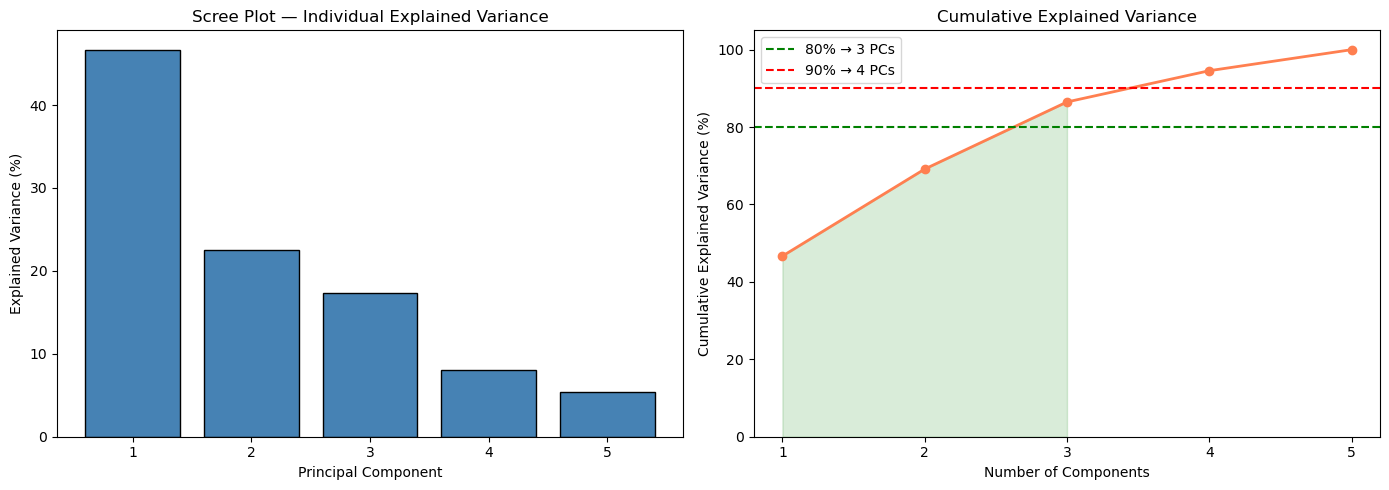

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Left: individual explained variance
axes[0].bar(range(1, len(explained)+1), explained * 100, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot — Individual Explained Variance')
axes[0].set_xticks(range(1, len(explained)+1))

# Right: cumulative explained variance
axes[1].plot(range(1, len(cumulative)+1), cumulative * 100, 'o-', color='coral', linewidth=2, markersize=6)
axes[1].axhline(y=80, color='green', linestyle='--', linewidth=1.5, label=f'80% → {n_80} PCs')
axes[1].axhline(y=90, color='red',   linestyle='--', linewidth=1.5, label=f'90% → {n_90} PCs')
axes[1].fill_between(range(1, n_80+1), 0, cumulative[:n_80]*100, alpha=0.15, color='green')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xticks(range(1, len(cumulative)+1))
axes[1].legend(fontsize=10)
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.show()

In [52]:

n_show = min(5, len(pca_features))  # show top PCs
# Readable labels
pca_label_map = {
    'square_feet': 'Square Feet',
    'bedrooms': 'Bedrooms', 'bathrooms': 'Bathrooms',
    'latitude': 'Latitude', 'longitude': 'Longitude',
}

loadings = pd.DataFrame(
    pca_full.components_[:n_show],
    columns=pca_features,
    index=[f'PC{i+1} ({explained[i]*100:.1f}%)' for i in range(n_show)]
)

# Rename columns for readability
loadings.columns = [pca_label_map.get(c, c.replace('_', ' ').title()) for c in loadings.columns]

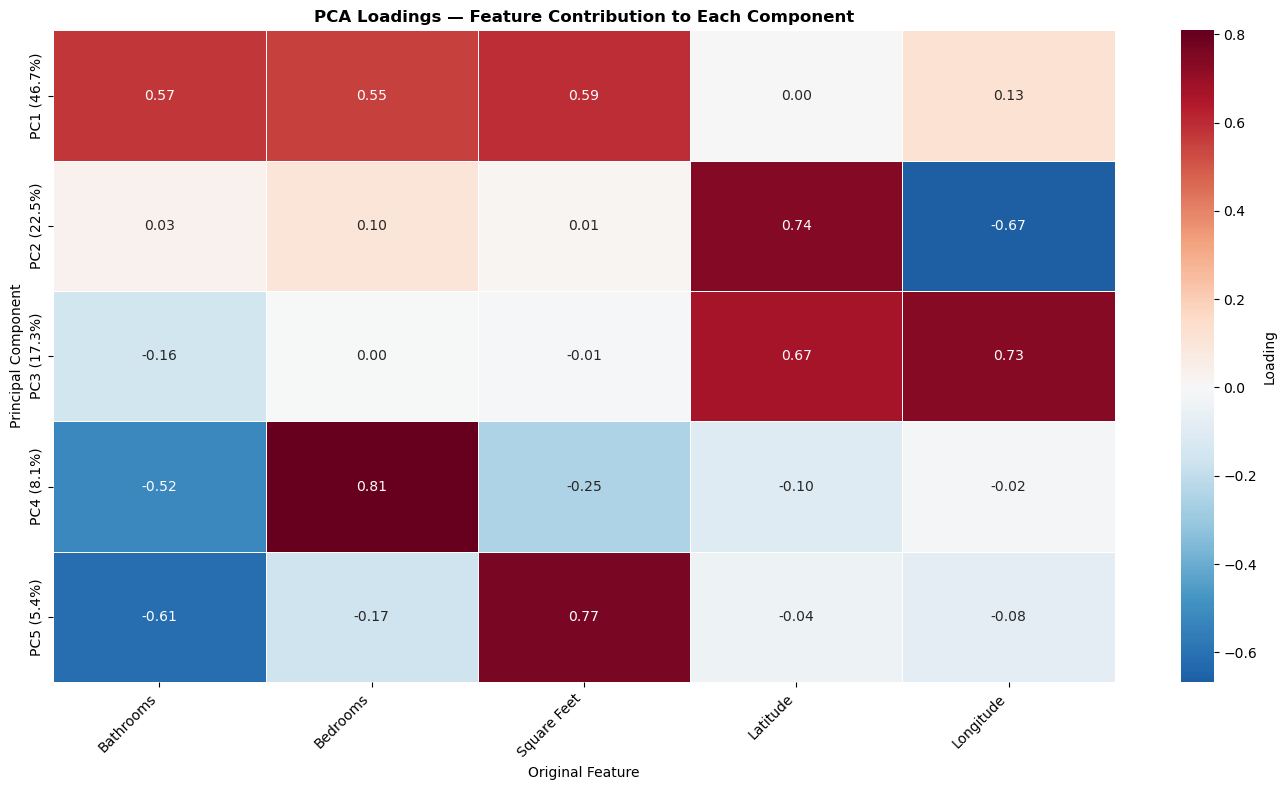

In [53]:
plt.figure(figsize=(14, n_show * 1.2 + 2))
sns.heatmap(
    loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    linewidths=0.5, cbar_kws={'label': 'Loading'}
)
plt.title('PCA Loadings — Feature Contribution to Each Component', fontweight='bold')
plt.xlabel('Original Feature')
plt.ylabel('Principal Component')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

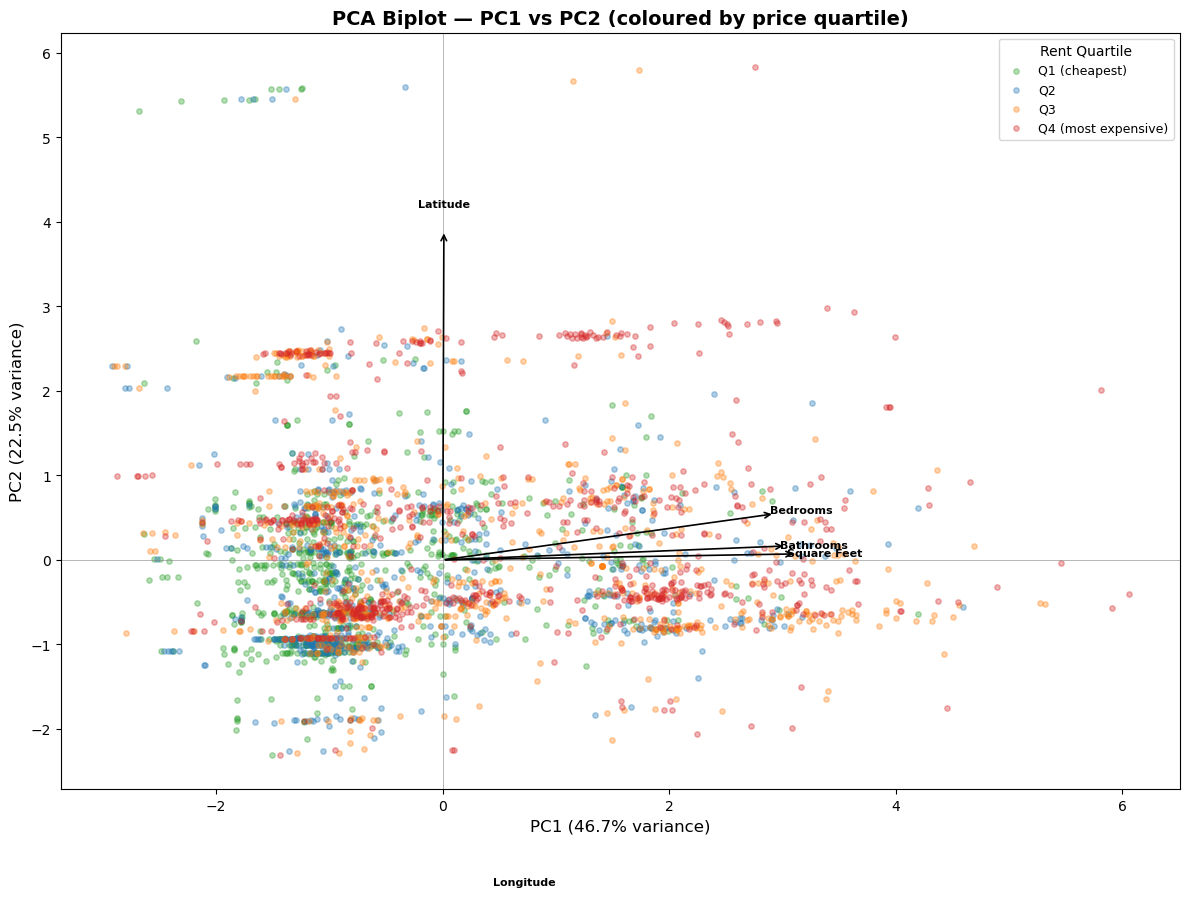

In [54]:

scores = pca_full.transform(X_pca)  # (n, k) — projections onto all PCs

# Build a working dataframe aligned to X_pca's index
biplot_df = pd.DataFrame({
    'PC1': scores[:, 0],
    'PC2': scores[:, 1],
    'price': df.loc[X_pca.index, 'price']
})

biplot_df['Price Quartile'] = pd.qcut(
    biplot_df['price'], q=4,
    labels=['Q1 (cheapest)', 'Q2', 'Q3', 'Q4 (most expensive)']
)

# Readable feature names
readable = [pca_label_map.get(c, c.replace('_', ' ').title()) for c in pca_features]

fig, ax = plt.subplots(figsize=(12, 9))

# Scatter (subsample for speed & clarity)
sample = biplot_df.sample(n=min(3000, len(biplot_df)), random_state=42)
palette = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728']
for i, (q, grp) in enumerate(sample.groupby('Price Quartile', observed=True)):
    ax.scatter(grp['PC1'], grp['PC2'], alpha=0.35, s=15, label=q, color=palette[i])

# Feature loading vectors
comps = pca_full.components_[:2]
scale_factor = max(np.abs(scores[:, :2]).max(axis=0)) * 0.8
for j, feat in enumerate(readable):
    ax.annotate(
        '', xy=(comps[0, j] * scale_factor, comps[1, j] * scale_factor),
        xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color='black', lw=1.2)
    )
    ax.text(
        comps[0, j] * scale_factor * 1.08,
        comps[1, j] * scale_factor * 1.08,
        feat, fontsize=8, ha='center', va='center', fontweight='bold'
    )

ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}% variance)", fontsize=12)
ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}% variance)", fontsize=12)
ax.set_title('PCA Biplot — PC1 vs PC2 (coloured by price quartile)', fontweight='bold', fontsize=14)
ax.legend(title='Rent Quartile', loc='best', fontsize=9)
ax.axhline(0, color='grey', lw=0.4)
ax.axvline(0, color='grey', lw=0.4)
plt.tight_layout()
plt.show()

### PCA Interpretation



**Can we summarise apartment characteristics in 2–3 dimensions?**

The scree plot shows that the first 2–3 principal components explain a **moderate** share of total variance. Because the input features span different domains (size, geography, time), variance is spread across several dimensions. This means:

- **2 components** capture the most important variation (size and geography) but miss temporal signals.
- **3–5 components** are needed to reach ≥ 80 % cumulative variance.
- A full low-dimensional summary in just 2–3 axes is **partially effective**: it preserves the strongest patterns (size drives rent, location matters) but compresses subtler signals.

> **Bottom line:** PCA confirms that apartment size and location are the dominant latent dimensions, while remaining features contribute smaller, independent dimensions — consistent with the feature-importance rankings from the regression models.

### Features Extracting

In [55]:
df_model = df.copy()

df_model['log_price'] = np.log1p(df_model['price'])
# Amenity Feature Extraction
print("=== Amenity Feature Extraction ===")
df_model['amenities_clean'] = df_model['amenities'].fillna('').str.lower()

amenity_patterns = {
    'has_parking': 'parking|garage',
    'has_laundry': 'laundry|washer|dryer',
    'has_pool': 'pool',
    'has_gym': 'gym|fitness|exercise',
    'has_ac': 'air conditioning|ac|a/c|hvac',
    'has_dishwasher': 'dishwasher',
    'has_balcony': 'balcony|patio|deck|terrace',
    'has_hardwood': 'hardwood|wood floor',
    'has_fireplace': 'fireplace',
    'has_doorman': 'doorman|concierge|24.hour|security',
    'has_elevator': 'elevator',
    'has_storage': 'storage',
    'is_furnished': 'furnished',
    'has_cable': 'cable|internet|wifi',
    'has_view': 'view|scenic'
}
for feature, pattern in amenity_patterns.items():
    df_model[feature] = df_model['amenities_clean'].str.contains(pattern, regex=True).astype(int)
    pct = df_model[feature].mean() * 100
    print(f"  {feature}: {df_model[feature].sum()} listings ({pct:.1f}%)")

amenity_cols = list(amenity_patterns.keys())
df_model['amenity_count'] = df_model[amenity_cols].sum(axis=1)
print(f"\n  amenity_count: mean={df_model['amenity_count'].mean():.1f}, max={df_model['amenity_count'].max()}")

=== Amenity Feature Extraction ===
  has_parking: 3544 listings (40.1%)
  has_laundry: 3622 listings (41.0%)
  has_pool: 3130 listings (35.4%)
  has_gym: 1406 listings (15.9%)
  has_ac: 2450 listings (27.7%)
  has_dishwasher: 2985 listings (33.8%)
  has_balcony: 2332 listings (26.4%)
  has_hardwood: 317 listings (3.6%)
  has_fireplace: 982 listings (11.1%)
  has_doorman: 26 listings (0.3%)
  has_elevator: 600 listings (6.8%)
  has_storage: 1473 listings (16.7%)
  is_furnished: 0 listings (0.0%)
  has_cable: 1986 listings (22.5%)
  has_view: 137 listings (1.6%)

  amenity_count: mean=2.8, max=12


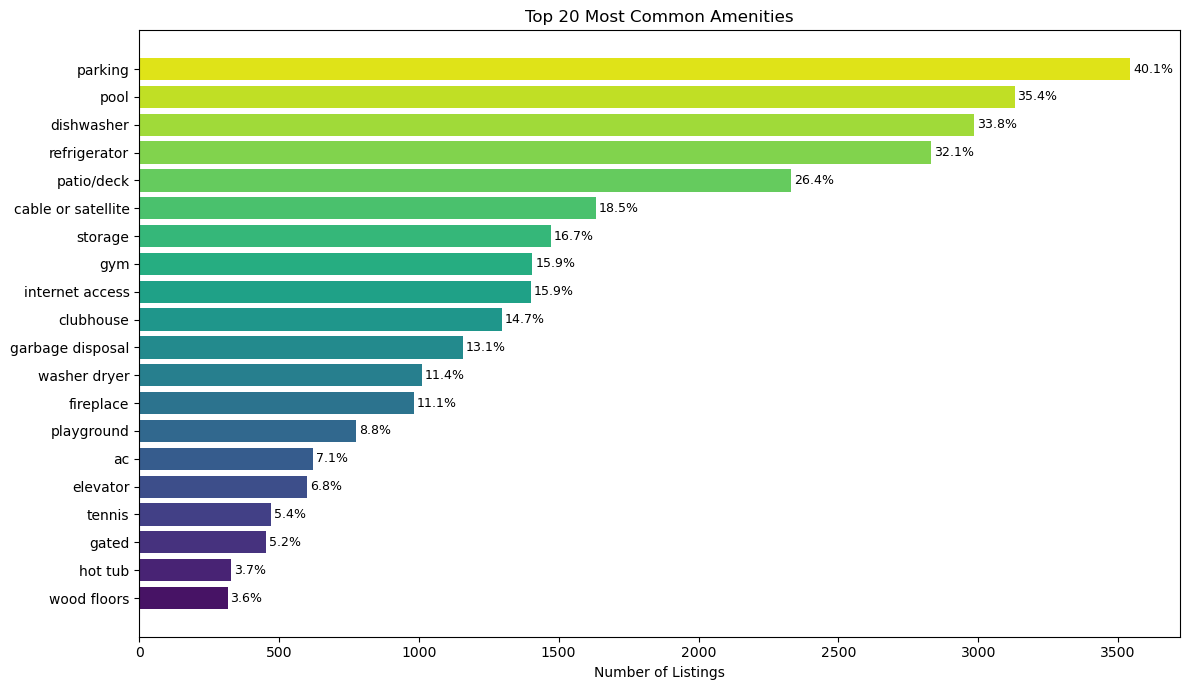

In [56]:
from collections import Counter

all_amenities = Counter()
df['amenities'].fillna('').apply(
    lambda x: [a.strip().lower() for a in str(x).split(',') if a.strip()]
).apply(all_amenities.update)

top_n = 20
top_amenities = all_amenities.most_common(top_n)
amenity_names = [a[0] for a in top_amenities]
amenity_counts = [a[1] for a in top_amenities]

fig, ax = plt.subplots(figsize=(12, 7))

# Bar chart of top amenities
colors = sns.color_palette('viridis', top_n)
ax.barh(amenity_names[::-1], amenity_counts[::-1], color=colors)
ax.set_xlabel('Number of Listings')
ax.set_title(f'Top {top_n} Most Common Amenities')
for i, (name, cnt) in enumerate(zip(amenity_names[::-1], amenity_counts[::-1])):
    ax.text(cnt + 10, i, f'{cnt/len(df)*100:.1f}%', va='center', fontsize=9)


plt.tight_layout()
plt.show()

In [57]:
# Pet Policy Features
df_model['pets_allowed_binary'] = df_model['pets_allowed'].apply(
    lambda x: 1 if x not in ['None', 'Not specified'] else 0
)



In [58]:
#text features
luxury_keywords = 'luxury|premium|exclusive|upscale|high.end|modern|renovated|updated'
df_model['is_luxury'] = df_model['title'].fillna('').str.lower().str.contains(luxury_keywords, regex=True).astype(int)


In [59]:

feature_cols = [
    # Core numeric
    'square_feet', 'bedrooms', 'bathrooms',
    # Amenities (15 binary)
    'has_parking', 'has_laundry', 'has_pool', 'has_gym', 'has_ac',
    'has_dishwasher', 'has_balcony', 'has_hardwood', 'has_fireplace',
    'has_doorman', 'has_elevator', 'has_storage','has_view',
    # Pets
    'pets_allowed_binary',
    # Location (coordinates only — target encoding added after split)
    'latitude', 'longitude',
    # Text
    'is_luxury',
]

#Keep 'state' for target encoding after the split
df_final = df_model[feature_cols + ['state', 'price', 'log_price']].copy()
print("\nFinal df shape (before cleaning):", df_final.shape)
df_final.dropna(inplace=True)
print("Final df shape (after dropna):", df_final.shape)
df_final.replace([np.inf, -np.inf], np.nan, inplace=True)
df_final.dropna(inplace=True)


print("FEATURE SET SUMMARY")
print(f"  Dataset rows: {len(df_final)}")


Final df shape (before cleaning): (8831, 23)
Final df shape (after dropna): (8760, 23)
FEATURE SET SUMMARY
  Dataset rows: 8760


## Models to predict the price

In [60]:
df_final.drop(columns=['price'], inplace=True)

In [61]:
#check vif there is multicollinearity between the core numeric features (square_feet, bedrooms, bathrooms) using VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# all numeric features
vif_features = df_final.select_dtypes(include=['float64', 'int64']).columns.tolist()
X_vif = df_final[vif_features].dropna()
X_vif_const = add_constant(X_vif)

vif_df = pd.DataFrame({
    'Feature': vif_features,
    'VIF': [variance_inflation_factor(X_vif_const.values, i+1) for i in range(len(vif_features))]
}).sort_values('VIF', ascending=False)

print("=== Variance Inflation Factor ===")
print(vif_df.to_string(index=False))

=== Variance Inflation Factor ===
            Feature      VIF
     has_dishwasher 4.578341
        has_laundry 4.544553
        square_feet 2.665783
          bathrooms 2.259872
             has_ac 1.966845
           bedrooms 1.910622
      has_fireplace 1.638817
        has_balcony 1.515814
           has_pool 1.498730
            has_gym 1.439089
        has_parking 1.367201
          log_price 1.256943
        has_storage 1.224674
       has_elevator 1.194126
          longitude 1.126071
           latitude 1.122509
pets_allowed_binary 1.114636
       has_hardwood 1.064183
           has_view 1.048311
        has_doorman 1.033808
          is_luxury 1.017801


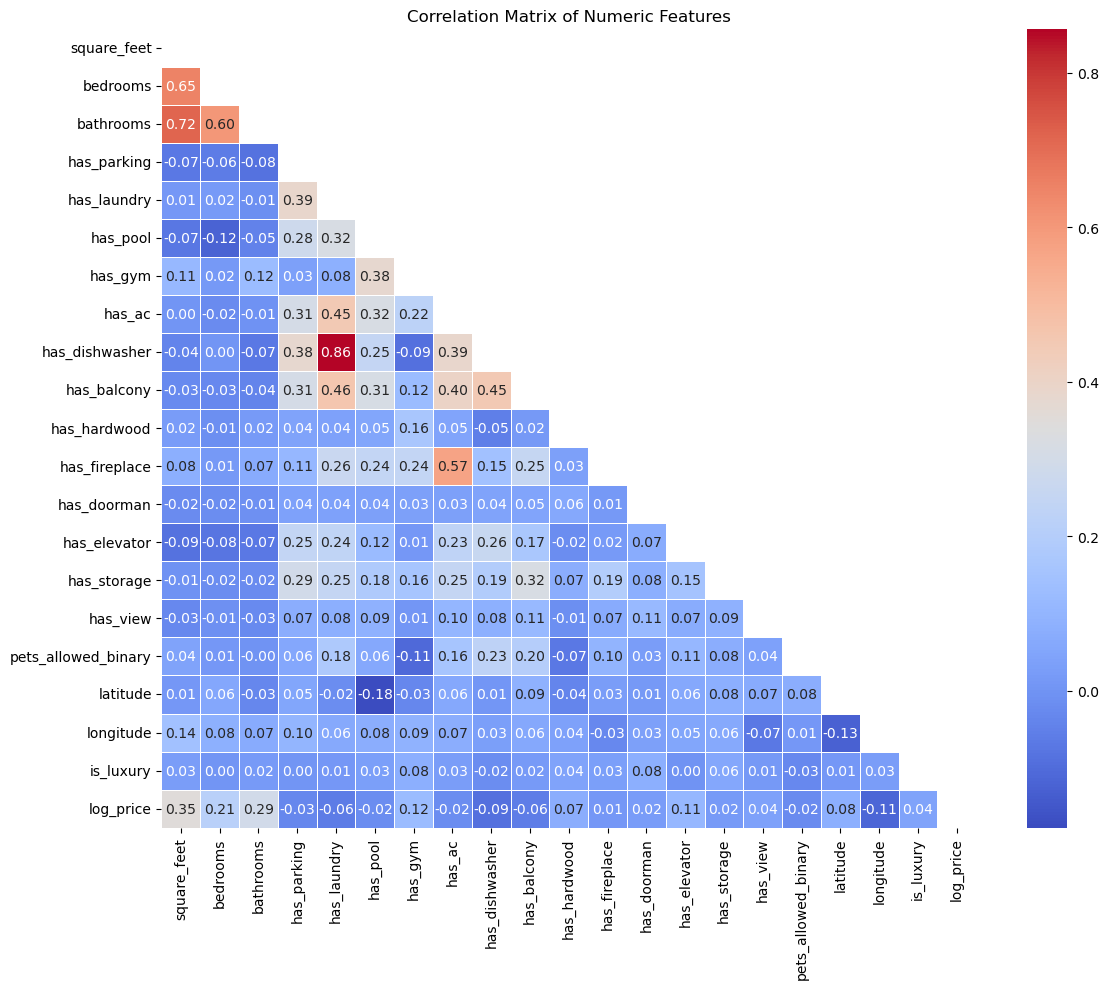

In [62]:
# plot the correlation matrix of the numeric features (including the target) to visually inspect multicollinearity but in only one half of the matrix to avoid redundancy
numeric_cols = df_final.select_dtypes(include=['float64', 'int64']).columns.tolist()
plt.figure(figsize=(12, 10))
corr_matrix = df_final[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

#### OLS Regression


In [63]:
#TRAIN-TEST SPLIT

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm

# Prepare data split before target encoding to prevent leakage
X = df_final[feature_cols].astype(float)
y = df_final['log_price'].astype(float)
y_raw = np.expm1(y)  # Reconstruct raw price from log_price
states = df_final['state']  # Keep state for target encoding

# Train-test split (80-20)
X_train, X_test, y_train, y_test, y_train_raw, y_test_raw, states_train, states_test = \
    train_test_split(X, y, y_raw, states, test_size=0.2, random_state=42)

In [64]:

print("=== Target Encoding (train-only, log-scale) ===")
global_mean_log = y_train.mean()   

# State average log-price — from training set only so no data leakage(LFD)
state_mean_train = y_train.groupby(states_train).mean()
X_train['state_avg_price'] = states_train.map(state_mean_train).values
X_test['state_avg_price']  = states_test.map(state_mean_train).fillna(global_mean_log).values

# State median log-price — from training set only
state_median_train = y_train.groupby(states_train).median()
X_train['state_median_price'] = states_train.map(state_median_train).values
X_test['state_median_price']  = states_test.map(state_median_train).fillna(global_mean_log).values

# Update feature_cols to include target-encoded features
feature_cols_full = feature_cols + ['state_avg_price', 'state_median_price']
unseen = set(states_test.unique()) - set(states_train.unique())


# Scale features for ALL models (needed for fair coefficient comparison)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols_full, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),  columns=feature_cols_full, index=X_test.index)


=== Target Encoding (train-only, log-scale) ===


In [65]:
def evaluate_model(name, y_train_true, y_train_pred, y_test_true, y_test_pred):
    """Return dict with train & test metrics for overfitting comparison."""
    train_r2   = r2_score(y_train_true, y_train_pred)
    test_r2    = r2_score(y_test_true,  y_test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))
    test_rmse  = np.sqrt(mean_squared_error(y_test_true,  y_test_pred))
    train_mae  = mean_absolute_error(y_train_true, y_train_pred)
    test_mae   = mean_absolute_error(y_test_true,  y_test_pred)
    test_mape  = np.mean(np.abs((y_test_true - y_test_pred) / y_test_true)) * 100

    gap = train_r2 - test_r2
    flag = "overfitting" if gap > 0.05 else ""

    print(f"\n  {'Metric':<12} {'Train':>10} {'Test':>10} {'Gap':>10}")
    print(f"  {'-'*44}")
    print(f"  {'R²':<12} {train_r2:>10.4f} {test_r2:>10.4f} {gap:>+10.4f}{flag}")
    print(f"  {'RMSE ($)':<12} {train_rmse:>10.0f} {test_rmse:>10.0f}")
    print(f"  {'MAE ($)':<12} {train_mae:>10.0f} {test_mae:>10.0f}")
    print(f"  {'MAPE (%)':<12} {'':>10} {test_mape:>10.1f}")

    return {
        'Train_R2': train_r2, 'Test_R2': test_r2, 'R2_Gap': gap,
        'R2': test_r2, 'RMSE': test_rmse, 'MAE': test_mae, 'MAPE': test_mape
    }

In [66]:
# OLS REGRESSION (Full — all features, scaled data)
# Fit on scaled training data
X_train_sc_const = sm.add_constant(X_train_scaled)
X_test_sc_const  = sm.add_constant(X_test_scaled)
ols_model = sm.OLS(y_train, X_train_sc_const).fit()


y_pred_train_raw_ols = np.expm1(ols_model.predict(X_train_sc_const))
y_pred_test_raw_ols  = np.expm1(ols_model.predict(X_test_sc_const))

results = {}
results['OLS Full'] = evaluate_model(
    'OLS Full', y_train_raw, y_pred_train_raw_ols, y_test_raw, y_pred_test_raw_ols
)
results['OLS Full']['AIC'] = ols_model.aic
results['OLS Full']['n_features'] = len(feature_cols_full)

print(f"\n  AIC: {ols_model.aic:.1f}")
print(f"\n=== OLS Coefficients (scaled — comparable magnitudes) ===")
coef_df = pd.DataFrame({
    'Feature': ols_model.params.index[1:],
    'Coefficient': ols_model.params.values[1:],
    'P-value': ols_model.pvalues.values[1:]
}).sort_values('P-value')
print(coef_df.to_string(index=False))


  Metric            Train       Test        Gap
  --------------------------------------------
  R²               0.5325     0.5240    +0.0085
  RMSE ($)            331        342
  MAE ($)             243        252
  MAPE (%)                      21.0

  AIC: 640.1

=== OLS Coefficients (scaled — comparable magnitudes) ===
            Feature  Coefficient       P-value
        square_feet     0.130479 8.486522e-155
       has_elevator     0.043035  2.240712e-39
    state_avg_price     0.317606  1.428967e-24
          longitude    -0.022260  6.625510e-12
          bathrooms     0.026670  4.971788e-09
pets_allowed_binary     0.017251  8.840375e-08
        has_parking     0.016995  1.716489e-06
             has_ac    -0.020142  2.364135e-06
       has_hardwood     0.010238  1.026608e-03
 state_median_price    -0.089396  3.676731e-03
        has_balcony    -0.010071  6.743419e-03
            has_gym     0.009257  1.097253e-02
           has_view     0.006936  2.493134e-02
        has_do

In [67]:
#Model Reduction: Backward Elimination
print("="*60)
print("MODEL 2: REDUCED OLS — BACKWARD ELIMINATION (Scaled)")
print("="*60)
print(f"\n  Starting with {len(feature_cols_full)} features, targeting ≤ 10")
print(f"  Stopping rule: ≤ 10 features AND all p-values < 0.05\n")

remaining = list(feature_cols_full)
step = 0

while True:
    X_step = sm.add_constant(X_train_scaled[remaining])
    model_step = sm.OLS(y_train, X_step).fit()
    pvalues = model_step.pvalues.drop('const')
    worst_pval = pvalues.max()
    worst_feat = pvalues.idxmax()

    # Stop: ≤ 10 features and all remaining are significant
    if len(remaining) <= 10 and worst_pval < 0.05:
        break
    # Safety: never drop below 1 feature
    if len(remaining) <= 1:
        break

    remaining.remove(worst_feat)
    step += 1
    print(f"  Step {step:2d}: removed '{worst_feat:<22}' "
          f"(p={worst_pval:.4f})  →  {len(remaining):2d} features left")


print(f"  Features: {remaining}")

#Final reduced model 
selected_features_list = remaining
X_train_reduced = sm.add_constant(X_train_scaled[selected_features_list])
X_test_reduced  = sm.add_constant(X_test_scaled[selected_features_list])

reduced_model = sm.OLS(y_train, X_train_reduced).fit()


y_pred_train_raw_reduced = np.expm1(reduced_model.predict(X_train_reduced))
y_pred_test_raw_reduced  = np.expm1(reduced_model.predict(X_test_reduced))

results['OLS Reduced'] = evaluate_model(
    'OLS Reduced', y_train_raw, y_pred_train_raw_reduced, y_test_raw, y_pred_test_raw_reduced
)
results['OLS Reduced']['AIC'] = reduced_model.aic
results['OLS Reduced']['n_features'] = len(selected_features_list)

print(f"\n  AIC  — Reduced: {reduced_model.aic:.1f}  |  Full: {ols_model.aic:.1f}")
aic_diff = ols_model.aic - reduced_model.aic
print(f"  AIC improvement vs full: {aic_diff:+.1f} "
      f"({'reduced is better' if aic_diff > 0 else 'full is better'})")

print(f"\n=== Reduced OLS Coefficients (scaled, {len(selected_features_list)} features) ===")
reduced_coef_df = pd.DataFrame({
    'Feature':     reduced_model.params.index[1:],
    'Coefficient': reduced_model.params.values[1:],
    'P-value':     reduced_model.pvalues.values[1:]
}).sort_values('Coefficient', key=abs, ascending=False)
print(reduced_coef_df.to_string(index=False))


MODEL 2: REDUCED OLS — BACKWARD ELIMINATION (Scaled)

  Starting with 22 features, targeting ≤ 10
  Stopping rule: ≤ 10 features AND all p-values < 0.05

  Step  1: removed 'has_fireplace         ' (p=0.9864)  →  21 features left
  Step  2: removed 'has_pool              ' (p=0.9574)  →  20 features left
  Step  3: removed 'has_dishwasher        ' (p=0.8693)  →  19 features left
  Step  4: removed 'is_luxury             ' (p=0.7221)  →  18 features left
  Step  5: removed 'bedrooms              ' (p=0.2262)  →  17 features left
  Step  6: removed 'has_laundry           ' (p=0.2295)  →  16 features left
  Step  7: removed 'latitude              ' (p=0.1236)  →  15 features left
  Step  8: removed 'has_storage           ' (p=0.0677)  →  14 features left
  Step  9: removed 'has_doorman           ' (p=0.0348)  →  13 features left
  Step 10: removed 'has_view              ' (p=0.0181)  →  12 features left
  Step 11: removed 'has_gym               ' (p=0.0054)  →  11 features left
  Step 12:

#### Random Forest

In [68]:

from sklearn.ensemble import RandomForestRegressor

print("="*60)
print("MODEL 3: RANDOM FOREST REGRESSOR")
print("="*60)

# Constrain tree depth to reduce overfitting
rf_params = {
    'n_estimators': [200, 300],
    'max_depth': [8, 12, 16],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [4, 8]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_cv = GridSearchCV(rf, rf_params, cv=5, scoring='r2', n_jobs=-1, verbose=1)
rf_cv.fit(X_train, y_train)

print(f"\n  Best params: {rf_cv.best_params_}")
print(f"  Best CV R2: {rf_cv.best_score_:.4f}")

MODEL 3: RANDOM FOREST REGRESSOR
Fitting 5 folds for each of 24 candidates, totalling 120 fits

  Best params: {'max_depth': 16, 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 300}
  Best CV R2: 0.6847


In [69]:
# Predictions (log to dollars)
y_pred_train_raw_rf = np.expm1(rf_cv.predict(X_train))
y_pred_test_raw_rf  = np.expm1(rf_cv.predict(X_test))

results['Random Forest'] = evaluate_model(
    'RF', y_train_raw, y_pred_train_raw_rf, y_test_raw, y_pred_test_raw_rf
)


# Feature importance
rf_importance = pd.DataFrame({
    'Feature': feature_cols_full,
    'Importance': rf_cv.best_estimator_.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\n Top 10 Most Important Features (Random Forest) ")
print(rf_importance.head(10).to_string(index=False))


  Metric            Train       Test        Gap
  --------------------------------------------
  R²               0.8492     0.6928    +0.1563overfitting
  RMSE ($)            188        274
  MAE ($)             131        193
  MAPE (%)                      16.2

 Top 10 Most Important Features (Random Forest) 
            Feature  Importance
    state_avg_price    0.333842
        square_feet    0.235434
 state_median_price    0.116130
           latitude    0.110035
          longitude    0.097791
          bathrooms    0.026759
           bedrooms    0.015758
       has_elevator    0.014240
pets_allowed_binary    0.009651
        has_parking    0.006976


#### CatBoost

In [70]:
from catboost import CatBoostRegressor, Pool

print("=" * 60)
print("MODEL 4: CATBOOST REGRESSOR")
print("=" * 60)

# CatBoost with early stopping using a validation split from training data
X_cb_train, X_cb_val, y_cb_train, y_cb_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

cb_model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.05,
    depth=7,
    l2_leaf_reg=5,
    min_data_in_leaf=10,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=200
)

cb_model.fit(
    X_cb_train, y_cb_train,
    eval_set=(X_cb_val, y_cb_val),
    early_stopping_rounds=100
)

print(f"\n  Best iteration: {cb_model.get_best_iteration()}")

MODEL 4: CATBOOST REGRESSOR
0:	learn: 0.3636721	test: 0.3667758	best: 0.3667758 (0)	total: 60.6ms	remaining: 2m 1s
200:	learn: 0.2091341	test: 0.2242809	best: 0.2242809 (200)	total: 484ms	remaining: 4.33s
400:	learn: 0.1868816	test: 0.2105558	best: 0.2105558 (400)	total: 893ms	remaining: 3.56s
600:	learn: 0.1731362	test: 0.2032709	best: 0.2032709 (600)	total: 1.33s	remaining: 3.09s
800:	learn: 0.1627525	test: 0.1990002	best: 0.1989948 (799)	total: 1.81s	remaining: 2.72s
1000:	learn: 0.1544903	test: 0.1967405	best: 0.1967081 (993)	total: 2.22s	remaining: 2.21s
1200:	learn: 0.1474272	test: 0.1949761	best: 0.1949761 (1200)	total: 2.62s	remaining: 1.75s
1400:	learn: 0.1412738	test: 0.1938965	best: 0.1938949 (1397)	total: 3.05s	remaining: 1.3s
1600:	learn: 0.1355794	test: 0.1932352	best: 0.1932207 (1568)	total: 3.46s	remaining: 863ms
1800:	learn: 0.1302005	test: 0.1926349	best: 0.1926291 (1798)	total: 3.88s	remaining: 429ms
1999:	learn: 0.1251679	test: 0.1923318	best: 0.1923237 (1997)	total

In [71]:
# CatBoost — Predictions & Evaluation (log → dollars)
y_pred_train_raw_cb = np.expm1(cb_model.predict(X_train))
y_pred_test_raw_cb  = np.expm1(cb_model.predict(X_test))

results['CatBoost'] = evaluate_model(
    'CatBoost', y_train_raw, y_pred_train_raw_cb, y_test_raw, y_pred_test_raw_cb
)

# Feature importance
cb_importance = pd.DataFrame({
    'Feature': feature_cols_full,
    'Importance': cb_model.get_feature_importance()
}).sort_values('Importance', ascending=False)

print(f"\n  Top 10 Most Important Features (CatBoost)")
print(cb_importance.head(10).to_string(index=False))


  Metric            Train       Test        Gap
  --------------------------------------------
  R²               0.8574     0.7225    +0.1349overfitting
  RMSE ($)            183        261
  MAE ($)             127        185
  MAPE (%)                      15.3

  Top 10 Most Important Features (CatBoost)
            Feature  Importance
           latitude   18.728054
        square_feet   18.128322
          longitude   16.173706
    state_avg_price   13.512739
 state_median_price   12.101195
          bathrooms    4.322610
           bedrooms    3.293553
pets_allowed_binary    2.141968
       has_elevator    2.130780
        has_parking    1.844081


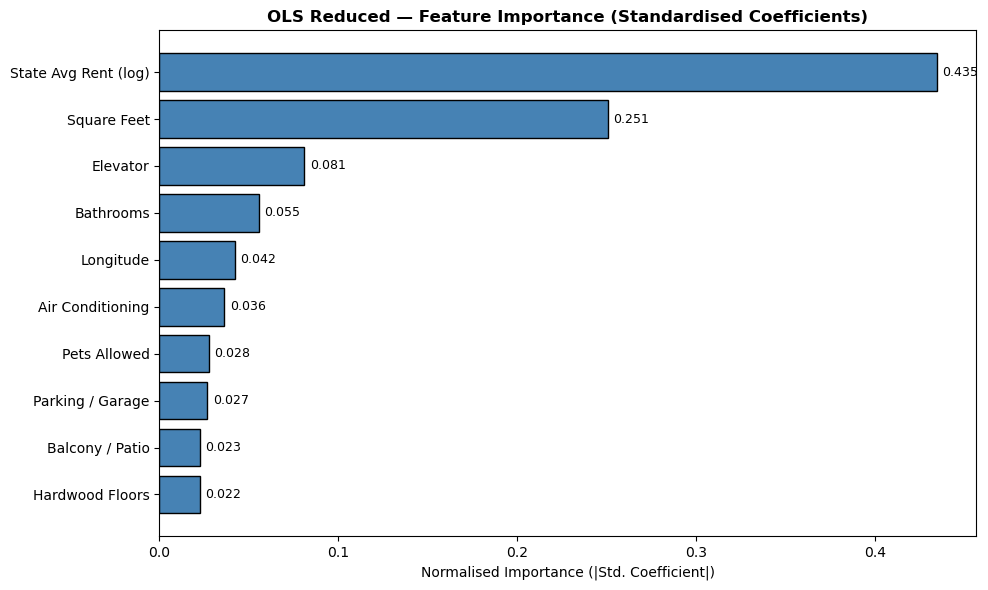

In [72]:
#FEATURE CONTRIBUTION — OLS (Reduced) vs RANDOM FOREST

# Human-readable labels for all features
label_map = {
    'square_feet':          'Square Feet',
    'bedrooms':             'Bedrooms',
    'bathrooms':            'Bathrooms',
    'has_parking':          'Parking / Garage',
    'has_laundry':          'Laundry / Washer',
    'has_pool':             'Swimming Pool',
    'has_gym':              'Gym / Fitness',
    'has_ac':               'Air Conditioning',
    'has_dishwasher':       'Dishwasher',
    'has_balcony':          'Balcony / Patio',
    'has_hardwood':         'Hardwood Floors',
    'has_fireplace':        'Fireplace',
    'has_doorman':          'Doorman / Security',
    'has_elevator':         'Elevator',
    'has_storage':          'Storage',
    'is_furnished':         'Furnished',
    'has_cable':            'Cable / Internet',
    'has_view':             'Scenic View',
    'pets_allowed_binary':  'Pets Allowed',
    'is_luxury':            'Luxury Listing',
    'latitude':             'Latitude',
    'longitude':            'Longitude',
    'state_avg_price':      'State Avg Rent (log)',
    'state_median_price':   'State Median Rent (log)',
}

# OLS: normalised absolute standardised coefficients
ols_abs = reduced_coef_df[['Feature', 'Coefficient']].copy()
ols_abs['Abs_Coef'] = ols_abs['Coefficient'].abs()
ols_abs['OLS_Importance'] = ols_abs['Abs_Coef'] / ols_abs['Abs_Coef'].sum()
ols_abs['Label'] = ols_abs['Feature'].map(label_map).fillna(ols_abs['Feature'])
ols_abs = ols_abs.sort_values('OLS_Importance', ascending=False)



#OLS Reduced
ols_plot = ols_abs.sort_values('OLS_Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(ols_plot['Label'], ols_plot['OLS_Importance'], color='steelblue', edgecolor='black')
ax.set_xlabel('Normalised Importance (|Std. Coefficient|)')
ax.set_title('OLS Reduced — Feature Importance (Standardised Coefficients)', fontweight='bold')
for i, val in enumerate(ols_plot['OLS_Importance']):
    ax.text(val + 0.003, i, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

MODEL COMPARISON SUMMARY
               Test_R2     RMSE      MAE    MAPE  Train_R2  R2_Gap  n_features
Model                                                                         
CatBoost        0.7225 260.8160 185.4849 15.3194    0.8574  0.1349         NaN
Random Forest   0.6928 274.4104 193.2245 16.2257    0.8492  0.1563         NaN
OLS Reduced     0.5243 341.4859 252.3055 20.9627    0.5304  0.0061     10.0000
OLS Full        0.5240 341.5792 252.4769 20.9594    0.5325  0.0085     22.0000

→ Best model by Test R²: CatBoost (R² = 0.7225)


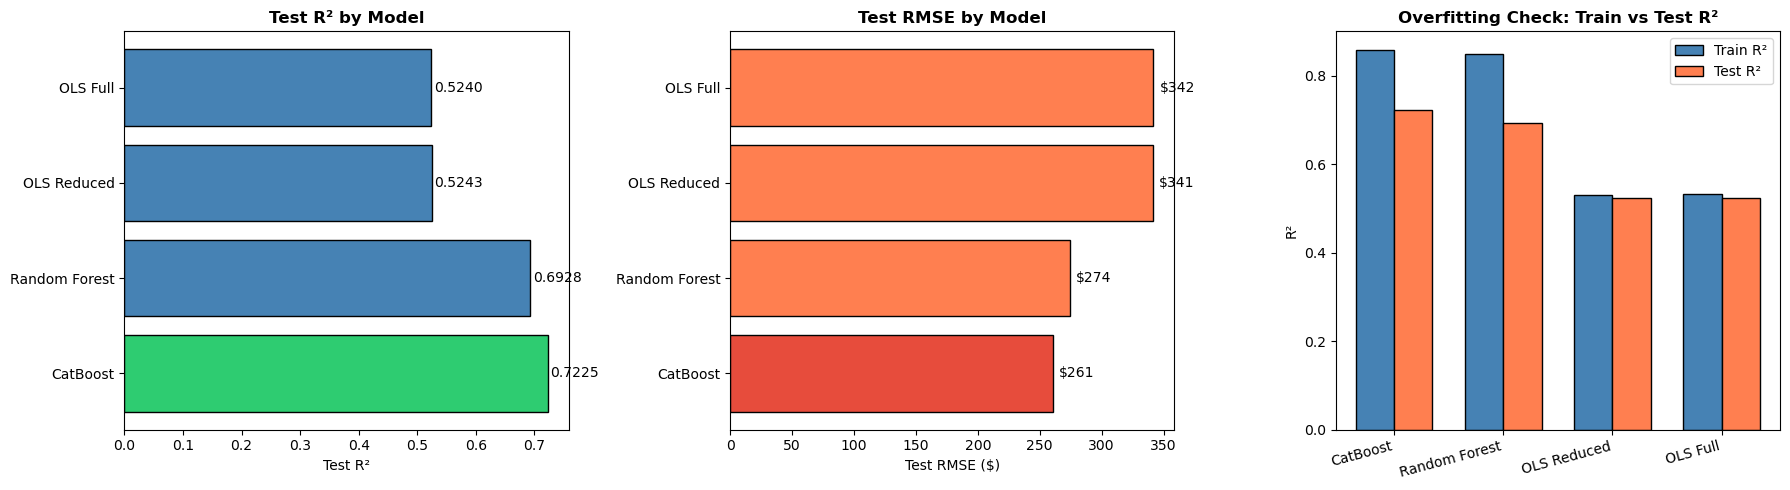

In [73]:
#MODEL COMPARISON SUMMARY ===
comparison = pd.DataFrame(results).T
comparison.index.name = 'Model'

# Select key columns in a readable order
display_cols = ['Test_R2', 'RMSE', 'MAE', 'MAPE', 'Train_R2', 'R2_Gap', 'n_features']
display_cols = [c for c in display_cols if c in comparison.columns]
comparison = comparison[display_cols].sort_values('Test_R2', ascending=False)

print("=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)
print(comparison.to_string(float_format=lambda x: f'{x:.4f}'))

# Highlight the best model
best_model = comparison['Test_R2'].idxmax()
print(f"\n→ Best model by Test R²: {best_model} (R² = {comparison.loc[best_model, 'Test_R2']:.4f})")

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = comparison.index.tolist()

# R² comparison
colors = ['#2ecc71' if m == best_model else 'steelblue' for m in models]
axes[0].barh(models, comparison['Test_R2'], color=colors, edgecolor='black')
axes[0].set_xlabel('Test R²')
axes[0].set_title('Test R² by Model', fontweight='bold')
for i, v in enumerate(comparison['Test_R2']):
    axes[0].text(v + 0.005, i, f'{v:.4f}', va='center')

# RMSE comparison
rmse_colors = ['#e74c3c' if m == best_model else 'coral' for m in models]
axes[1].barh(models, comparison['RMSE'], color=rmse_colors, edgecolor='black')
axes[1].set_xlabel('Test RMSE ($)')
axes[1].set_title('Test RMSE by Model', fontweight='bold')
for i, v in enumerate(comparison['RMSE']):
    axes[1].text(v + 5, i, f'${v:.0f}', va='center')

# Overfitting check (Train R² vs Test R²)
x = np.arange(len(models))
width = 0.35
axes[2].bar(x - width/2, comparison['Train_R2'], width, label='Train R²', color='steelblue', edgecolor='black')
axes[2].bar(x + width/2, comparison['Test_R2'], width, label='Test R²', color='coral', edgecolor='black')
axes[2].set_xticks(x)
axes[2].set_xticklabels(models, rotation=15, ha='right')
axes[2].set_ylabel('R²')
axes[2].set_title('Overfitting Check: Train vs Test R²', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()